# Setup

In [1]:
import math
import torch
import torch.distributions as tdist
import torchvision
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D  
import matplotlib.animation as pltanim
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.cluster import SpectralClustering, KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, pair_confusion_matrix
from sklearn.datasets import load_digits
import scipy.sparse as sprs
import kmedoids

from data import MET_Data
import utils

In [ ]:
merge_map = utils.get_tree_merge_map("/Users/ian.convy/code/cplAE_MET/data/meta/tree_Mouse_ALM-VISp_2018.csv", "n3")
def get_merge_func(index, merge_map = merge_map):
    merge_func = np.vectorize(lambda elem: merge_map[elem][index]) 
    return merge_func

def get_z_sample(mu, transf, gamma, num_samples = 1):
    (alpha, beta) = ((mu.shape[1] + 1)/2, 1/2)
    V = tdist.InverseGamma(alpha, beta).rsample(torch.as_tensor([num_samples]))[:, None]
    S = torch.randn_like(mu)
    z_samples = mu[None] + gamma[None]/V + torch.einsum("ij,nj->ni", transf, S)/V.sqrt()
    return z_samples

def get_dense(input_size, output_size, hidden_dims, actvs = None, final_bias = True):
    layer_sizes = [input_size] + hidden_dims + [output_size]
    if type(actvs) != list:
        actvs = [actvs]*len(layer_sizes[1:])
    layers = []
    for (i, (input_dim, output_dim, actv)) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:], actvs)):
        bias = (final_bias if i == len(hidden_dims) else True)
        layers.append(torch.nn.Linear(input_dim, output_dim, bias = bias))
        if actv is not None:
            layers.append(actv())
    return layers

def combine_losses(total_loss, cuml_losses, new_losses):
    incremented = {key:value + cuml_losses.get(key, 0) for (key, value) in new_losses.items()}
    cuml_total = cuml_losses.get("total", 0) + total_loss
    new_cuml = {**cuml_losses, **incremented, "total": cuml_total}
    return new_cuml

def plot_gradient(ax, decoder, scale = None, grad_range = [(-3, 3), (-3, 3)], grid_points = 50):
    n = grid_points + 1
    delta = 0.1
    x_points = torch.linspace(*grad_range[0], n)
    y_points = torch.linspace(*grad_range[1], n)
    z_grid = torch.stack(torch.meshgrid(x_points, y_points), -1)
    displ = torch.asarray([[delta, 0], [0, delta], [delta/2**0.5, delta/2**0.5], [delta/2**0.5, -delta/2**0.5]])
    (plus, minus) = (z_grid[:, :, None] + displ[None, None], z_grid[:, :, None] - displ[None, None])
    (plus_f, minus_f) = (plus.reshape(4*n**2, 2), minus.reshape(4*n**2, 2))
    with torch.no_grad():
        (output_plus, output_minus) = (decoder(plus_f.float()), decoder(minus_f.float()))
    grad = (output_plus - output_minus) / (2*delta)
    combined = abs(grad).reshape(n, n, 4, -1).sum(-1)
    (max_val, max_dir) = torch.max(combined, -1)
    (max_dir, max_val) = (max_dir.reshape(n, n), max_val.reshape(n, n))
    scale = max_val.max() if scale is None else scale
    max_val = max_val / scale

    lines = displ
    for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
        for (xy, dir, val) in zip(coords, row_dirs, row_vals):
            ((px_1, py_1), (px_2, py_2)) = (xy + lines[dir]*val, xy - lines[dir]*val)
            ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
    return (z_grid, combined)

def plot_raw_data(x, x_labels, ax, colors, marker_size = 20, **view_params):
    dim = x.shape[1]
    ax.scatter(*x.T[:3], s = marker_size, c = [colors[index] for index in x_labels])
    if dim >= 3:
        ax.set_aspect("equal")
        if view_params:
            ax.view_init(**view_params)

def plot_recon_data(x, x_recon, ax, marker_size = 20, **view_params):
    dim = x.shape[1]
    ax.scatter(*x.T[:3], s = marker_size)
    ax.scatter(*x_recon.T[:3], s = 2.5*marker_size, facecolors = "none", edgecolors = "r")
    for (orig_coords, recon_coords) in zip(x, x_recon):
        ax.plot(*zip(orig_coords[:3], recon_coords[:3]), color = "black", linewidth = 0.5)
    if dim >= 3:
        ax.set_aspect("equal")
        ax.view_init(**view_params)

def plot_latent(means, labels, ax, dec, colors, grad_range = [(-3, 3), (-3, 3)], grid_points = 50):
    if dec is not None:
        (z_grid, gradients) = plot_gradient(ax, dec, grad_range = grad_range, grid_points = grid_points)
    for (i, ((x, y), color_index)) in enumerate(zip(means, labels)):
        color = colors[color_index]
        ax.scatter([x], [y], s = 20, color = color)
    ax.set_aspect(1)
    ax.set_xlim(grad_range[0])
    ax.set_ylim(grad_range[1])

def get_kmedoids(z_means, metric_funcs, num_clusters, batch_size = 128, distance = True, **kwargs):
    num_samples = z_means.shape[0]
    clusters = {}
    for (method, func) in metric_funcs.items():
        batches = []
        for i in range(math.ceil(num_samples / batch_size)):
            source_i = torch.arange(i*batch_size, min((i+1)*batch_size, num_samples))
            dist = func(z_means = z_means, source_i = source_i, target_i = torch.arange(num_samples)[None], **kwargs)
            if not distance:
                dist = 1 / dist
            batches.append(dist)
        dist_matrix = torch.cat(batches)
        clusters[method] = kmedoids.KMedoids(num_clusters, random_state = 42).fit((dist_matrix + dist_matrix.T) / 2).labels_
    return clusters

def get_agglomerated(z_means, metric_funcs, num_clusters, batch_size = 128, distance = True, num_neighbors = None, **kwargs):
    clusters = {}
    connect_matrix = kneighbors_graph(z_means, num_neighbors, include_self = False) if num_neighbors else None
    for (method, func) in metric_funcs.items():
        dist_matrix = get_distance(z_means, func, kwargs, batch_size)
        if not distance:
            dist_matrix = 1 / dist_matrix
        model = AgglomerativeClustering(
            num_clusters, metric = "precomputed", linkage = "average", compute_full_tree = True, connectivity = connect_matrix).fit((dist_matrix + dist_matrix.T) / 2)
        clusters[method] = model.labels_
    return clusters

def get_distance(z_means, distance_func, kwargs, batch_size):
    num_samples = z_means.shape[0]
    batches = []
    for i in range(math.ceil(num_samples / batch_size)):
        source_i = torch.arange(i*batch_size, min((i+1)*batch_size, num_samples))
        dist = distance_func(z_means = z_means, source_i = source_i, target_i = torch.arange(num_samples)[None], **kwargs)
        batches.append(dist)
    dist_matrix = torch.cat(batches)
    return dist_matrix

def get_euclidean_distance(z_means, source_i, target_i, **kwargs):
    diff_vectors = z_means[source_i, None] - z_means[target_i]
    dist = torch.linalg.norm(diff_vectors, dim = -1)
    return dist

def get_decoded_distance(z_means, decoder, num_steps, source_i, target_i, batch_size = 1024, **kwargs):
    steps = torch.linspace(0, 1, num_steps + 1)
    diff_vectors = z_means[target_i] - z_means[source_i, None]
    step_vectors = z_means[None, source_i, None] + torch.einsum("s,nli->snli", steps, diff_vectors)
    flat_norms = []
    flat_vectors = step_vectors.flatten(1, 2).float()
    for batch in (flat_vectors[:, i*batch_size:(i+1)*batch_size] for i in range(math.ceil(flat_vectors.shape[1] / batch_size))):
        with torch.no_grad():
            step_recon = decoder(batch.flatten(0, 1)).unflatten(0, batch.shape[:2])
            flat_norms.append(torch.linalg.norm(step_recon[1:] - step_recon[:-1], dim = -1).sum(0))
    dist = torch.cat(flat_norms, 0).unflatten(0, step_vectors.shape[1:3])
    return dist

def get_hop_distance(z_means, decoder, source_i, target_i, **kwargs):
    return get_decoded_distance(z_means, decoder, 1, source_i, target_i)

class Encoder(torch.nn.Module):
    def __init__(self, input_dim, init_hidden, mean_hidden, transf_hidden, latent_dim):
        super().__init__()
        init_out = init_hidden[-1] if init_hidden else input_dim
        initial_layers = get_dense(input_dim, init_out, init_hidden[:-1], torch.nn.ReLU) if init_hidden else []
        mean_actvs = [torch.nn.ReLU]*len(mean_hidden) + [None]
        transf_actvs = [torch.nn.ReLU]*len(transf_hidden) + [None]

        self.initial_segment = torch.nn.Sequential(*initial_layers)
        self.mean_layer = torch.nn.Sequential(*get_dense(init_out, latent_dim, mean_hidden, mean_actvs, False))
        self.transf_layer = torch.nn.Sequential(*get_dense(init_out, latent_dim**2, transf_hidden, transf_actvs))
        
        self.softplus = torch.nn.Softplus()
        self.bn = torch.nn.BatchNorm1d(latent_dim, momentum = 0.05, affine = False)
        self.latent_dim = latent_dim
    
    def forward(self, x):
        x = self.initial_segment(x)
        # mean = self.bn(self.mean_layer(x))
        mean = self.mean_layer(x)
        transf_raw = self.transf_layer(x).reshape(-1, self.latent_dim, self.latent_dim)
        diagonals = self.softplus(torch.diagonal(transf_raw, 0, -2, -1)) + 1e-4
        transf = torch.diag_embed(diagonals) + torch.tril(transf_raw, -1)
        return (mean, transf)
    
class Decoder(torch.nn.Module):
    def __init__(self, output_dim, hidden_dims, latent_dim):
        super().__init__()
        actvs = [torch.nn.ReLU]*len(hidden_dims) + [None]
        self.network = torch.nn.Sequential(*get_dense(latent_dim, output_dim, hidden_dims, actvs))

    def forward(self, x):
        x = self.network(x)
        return x

class VariationalLoss():
    def __init__(self, recon_frac, num_samples = 1):
        self.num_samples = num_samples
        (self.recon_weight, self.reg_weight) = (recon_frac, 1 - recon_frac)
    
    def process_batch(self, enc, dec, x):
        (mu, sigma, gamma) = enc(x)
        recon_loss = self.get_recon_loss(enc, dec, x, mu, sigma, gamma, self.num_samples)
        reg_loss = self.get_reg_loss(mu, sigma, gamma)
        loss = self.recon_weight*recon_loss + self.reg_weight*reg_loss
        return loss

    def get_recon_loss(self, decoder, x, z_mean, z_transf, num_samples):
        z_sample = get_z_sample(z_mean, z_transf, num_samples)
        x_recon = decoder(z_sample.flatten(0, 1)).unflatten(0, z_sample.shape[:2]) 
        squared_diff = torch.square(x[:, None] - x_recon)
        loss = squared_diff.mean()
        return loss
    
    def get_cross_loss(self, out_decoder, x, cross_sample):
        xr = out_decoder(cross_sample.flatten(0, 1)).unflatten(0, cross_sample.shape[:2])
        loss = self.reconstruction_loss(x, xr)
        return loss

    def combine_losses(self, loss_dict, latent_dict, mapper_dict):
        (recon_weight, reg_weight) = (self.recon_frac, 1 - self.recon_frac)
        weighted_loss_dict = {}
        total_loss = 0
        for modal_1 in self.modalities:
            (mean_1, transf_1) = latent_dict[modal_1]
            losses = {
                "within": recon_weight*loss_dict[modal_1],
                "mean_reg": reg_weight*0.5*torch.square(mean_1).sum(1).mean() / self.within_var,
                "trace_reg": reg_weight*0.5*transf_1.square().mean(0).sum() / self.within_var,
                "det_reg": -reg_weight*0.5*(2*torch.log(torch.det(transf_1)).mean())
                }
            total_loss += sum(loss for loss in losses.values())
            weighted_loss_dict = {
                **weighted_loss_dict, 
                **{f"{modal_1}_{key}": loss for (key, loss) in losses.items()}}
            for modal_2 in self.modalities:
                if modal_1 != modal_2:
                    for (first, second) in [(modal_1, modal_2), (modal_2, modal_1)]:
                        (_, map_transf) = mapper_dict[f"{first}={second}"]
                        losses = {
                            "cross": self.cross_damp*recon_weight*loss_dict[f"{first}={second}"],
                            "map_trace_reg": reg_weight*0.5*map_transf.square().mean(0).sum() / self.cross_var,
                            "map_det_reg": -reg_weight*0.5*(2*torch.log(torch.det(map_transf)).mean()) / self.cross_var}
                        total_loss += sum(loss for loss in losses.values())
                        weighted_loss_dict = {
                            **weighted_loss_dict,
                            **{f"{first}-{second}_{key}": loss for (key, loss) in losses.items()}}
        return (weighted_loss_dict, total_loss)

def get_metric_loss(x, encoder, decoder, metric):
    mean = encoder(x)[0]
    z_transf = metric(mean)
    z_sample = get_z_sample(mean, z_transf, 10)
    x_mean = decoder(mean)
    xr = decoder(z_sample.flatten(0, 1)).unflatten(0, z_sample.shape[:2])
    squared_diff = torch.square(x_mean[:, None] - xr)
    recon_loss = squared_diff.sum() / (xr.shape[0]*xr.shape[1]) 
    trace_loss = 0.5*z_transf.square().mean(0).sum()
    det_loss = -0.5*2*torch.log(torch.diagonal(z_transf, 0, -2, -1)).sum(-1).mean()
    loss = recon_loss + trace_loss + det_loss
    return loss

class Dataset():
    def __init__(self):
        self.data = None
        self.labels = None
        self.max_samples = None
        self.num_clusters = None
        self.dims = None
        self.num_modalities = None

    def sample(self, samples_per_cluster, seed = 42):
        rand_gen = np.random.default_rng(seed)
        cluster_indices = [torch.nonzero(self.labels == label)[:, 0] for label in range(self.num_clusters)]
        sampled_indices = np.concatenate([rand_gen.choice(indices, samples_per_cluster, replace = False) 
                                          for indices in cluster_indices])
        rand_gen.shuffle(sampled_indices)
        sampled_data = [modal_data[sampled_indices].float() for modal_data in self.data]
        sampled_labels = self.labels[sampled_indices]
        return (sampled_data, sampled_labels)
    
    def get(self):
        data = [modal_data.float() for modal_data in self.data]
        return (data, self.labels)

class ClusterData(Dataset):
    def __init__(self, cluster_params, samples_per_cluster, seed = 42):
        self.num_clusters = len(cluster_params)
        self.dims = [len(mean) for mean in cluster_params[0]["means"]]
        self.num_modalities = len(self.dims)
        self.max_samples = samples_per_cluster*self.num_clusters
        self.seed = seed

        torch.manual_seed(seed)
        gaussian_params = [self.get_cluster_gaussian(**params) for params in cluster_params]
        samples = torch.cat([self.get_cluster_sample(gaussian_params[i], samples_per_cluster) for i in range(self.num_clusters)])
        self.data = [samples[slices] for slices in self.get_modal_slices()]
        self.labels = torch.arange(self.num_clusters).repeat_interleave(samples_per_cluster)
    
    def get_cluster_gaussian(self, means, vars, within_corrs, cross_corr):
        mean_comb = torch.as_tensor(means).flatten().float()
        within_blocks = {(i, i): self.get_modality_cov_block(self.dims[i], vars[i], within_corrs[i]) 
                         for i in range(self.num_modalities)}
        cross_blocks = {(i, j): self.get_cross_block(self.dims[i], self.dims[j], vars[i], vars[j], cross_corr)
                        for i in range(self.num_modalities) for j in range(self.num_modalities)
                        if i != j}
        blocks = {**within_blocks, **cross_blocks}
        cov = torch.cat([torch.cat([blocks[(i, j)] for j in range(self.num_modalities)], 1)
                         for i in range(self.num_modalities)], 0)
        transf = torch.linalg.cholesky(cov)
        return {"mean": mean_comb, "cov": cov, "transf": transf}
        
    def get_modality_cov_block(self, dim, var, corr):
        cov = torch.ones([dim, dim])*var*corr
        torch.diagonal(cov).copy_(var*torch.ones([dim]))
        return cov

    def get_cross_block(self, rows, cols, row_var, col_var, cross_corr):
        row_vec = torch.full([rows], row_var)
        col_vec = torch.full([cols], col_var)
        cross_block = cross_corr*torch.sqrt(row_vec[:, None]*col_vec[None])
        return cross_block

    def get_modal_slices(self):
        cuml_pos = np.insert(np.cumsum(self.dims[:-1]), 0, 0)
        modal_slices = [(slice(None), slice(int(pos), int(pos + dim), 1))
                         for (pos, dim) in zip(cuml_pos, self.dims)]
        return modal_slices
    
    def get_cluster_sample(self, params, num_samples):
        expanded_mean = params["mean"][None].expand(num_samples, -1)
        noise = torch.einsum("ij,sj->si", params["transf"], torch.randn_like(expanded_mean))
        samples = expanded_mean + noise
        return samples

class SwissRollData(Dataset):
    def __init__(self, num_clusters, samples_per_cluster, seed = 42):
        self.num_clusters = num_clusters
        self.num_modalities = 1
        self.dims = [3]
        self.max_samples = samples_per_cluster*self.num_clusters
    
        (roll_samples, rol_pos) = datasets.make_swiss_roll(n_samples = samples_per_cluster*self.num_clusters, hole = False, random_state = seed)
        pos_scaled = self.num_clusters * (rol_pos - rol_pos.min())/(rol_pos.max() - rol_pos.min())
        self.data = [torch.from_numpy(roll_samples[np.argsort(pos_scaled)])]
        self.labels = torch.arange(self.num_clusters).repeat(samples_per_cluster)
    
class Digits(Dataset):
    def __init__(self):
        self.num_modalities = 1
        self.num_clusters = 10
        self.dims = [64]
        self.max_samples = 1797

        mnist_data = load_digits()
        self.data = [torch.from_numpy(mnist_data.data / 16)]
        self.labels = torch.from_numpy(mnist_data.target)

class FashionMNIST(Dataset):
    def __init__(self):
        self.num_modalities = 1
        self.num_clusters = 10
        self.dims = [784]
        raw_data = list(torchvision.datasets.FashionMNIST("fashion", download = True))
        self.max_samples = len(raw_data)
    
        (images_raw, raw_labels) = zip(*raw_data)
        self.data = [torch.stack([torch.from_numpy(np.asarray(img)).flatten() / 255 for img in images_raw], 0)]
        self.labels = torch.as_tensor(raw_labels)

class MET(Dataset):
    def __init__(self):
        self.num_modalities = 1
        self.dims = [1252, 82]
        met = MET_Data("/Users/ian.convy/code/cplAE_MET/data/neurons.hdf5", **{"logcpm": "logcpm", "pca-ipfx": "pca-ipfx"})
        data = met.query(formats = [("logcpm", "pca-ipfx")], platforms = ["patchseq"], outputs = ["logcpm", "pca-ipfx", "cluster_label"])
        self.max_samples = len(data["cluster_label"])
        cluster_maps = {label: i for (i, label) in enumerate(np.unique(data["cluster_label"]))}
        self.num_clusters = len(cluster_maps)
        self.labels = torch.as_tensor([cluster_maps[label] for label in data["cluster_label"]])
        self.data = [torch.from_numpy(data["logcpm"]), torch.from_numpy(data["pca-ipfx"])]
    
def train_model(samples, var_loss, num_modalities, modality_dims, latent_dims, patience = 100):
    encoder_layers = [
        {"init_hidden": [], "mean_hidden": [100, 100], "transf_hidden": [100, 100]},
        {"init_hidden": [], "mean_hidden": [100, 100], "transf_hidden": [100, 100]}]
    decoder_layers = [[100, 100], [100, 100]]
    mapper_layers = [100, 100]
    metric_layers = [100]

    encoders = [Encoder(input_dim = modal_dim, latent_dim = latent_dim, **layers)
                for (modal_dim, latent_dim, layers) in zip(modality_dims, latent_dims, encoder_layers)]
    decoders = [Decoder(modal_dim, layers, latent_dim)
                for (modal_dim, latent_dim, layers) in zip(modality_dims, latent_dims, decoder_layers)]
    mappers = {(i, j): Mapper(mapper_layers, latent_dims[j]) 
            for i in range(num_modalities) for j in range(num_modalities) if i != j}
    metrics = [Metric(metric_layers, latent_dim)
            for (modal_dim, latent_dim, layers) in zip(modality_dims, latent_dims, decoder_layers)]
    model = torch.nn.ModuleDict({
        "encoders": torch.nn.ModuleList(encoders),
        "decoders": torch.nn.ModuleList(decoders),
        "mappers": torch.nn.ModuleList(list(mappers.values())),
        "metrics": torch.nn.ModuleList(metrics)})
    
    num_samples = len(samples[0])
    epochs = int(4000*10000/num_samples)
    batch_size = 1024
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
    metric_optimizer = torch.optim.Adam(model["metrics"].parameters())

    (best_loss, lag) = (np.inf, 0)
    for epoch in range(epochs):
        try:
            shuffled_indices = torch.randperm(num_samples)
            cuml_losses = {}
            batch_starts = list(range(0, num_samples, batch_size))
            for start in batch_starts:
                optimizer.zero_grad()
                batch_indices = shuffled_indices[start:start + batch_size]
                batched_data = [modal_samples[batch_indices] for modal_samples in samples]
                (loss_dict, loss) = var_loss.process_batch(encoders, decoders, mappers, batched_data)
                loss.backward()
                optimizer.step()
                metric_loss = sum([get_metric_loss(batched_data[i], encoders[i], decoders[i], metrics[i])
                                   for i in range(num_modalities)])
                metric_loss.backward()
                metric_optimizer.step()
                cuml_losses = combine_losses(loss, cuml_losses, loss_dict)
            avg_losses = {key: value / len(batch_starts) for (key, value) in cuml_losses.items()}
            total_loss = avg_losses["total"]
            if total_loss < best_loss:
                best_loss = total_loss
                lag = 0
            elif lag >= patience:
                break
            else:
                lag += 1
            print(f"Epoch {epoch + 1}: {avg_losses['total'].item():.4f}            ", end = "\r")
        except KeyboardInterrupt:
            break
    return (encoders, decoders, mappers, metrics)

def get_outputs(samples, encoders, decoders, metrics, mappers, num_modalities):
    with torch.no_grad():
        modal_means = [encoder(x)[0] for (x, encoder) in zip(samples, encoders)]
        mapped_recons = {(i, j): decoders[j](mapper(modal_means[i])[0]) for ((i, j), mapper) in mappers.items()} 
        direct_recons = {(i, i): decoder(z) for (i, (z, decoder)) in enumerate(zip(modal_means, decoders))}
        recons = {**direct_recons, **mapped_recons}
    
    (means, transfs, eig_vals, eig_vecs, rotations) = ({}, {}, {}, {}, {})
    with torch.no_grad():
        modal_latent = [encoder(x) for (x, encoder) in zip(samples, encoders)]
        for (in_modal, (mean, transf)) in enumerate(modal_latent):
            for out_modal in range(num_modalities):
                modals = (in_modal, out_modal)
                if in_modal != out_modal:
                    (mean, transf) = mappers[modals](mean)
                (means[modals], transfs[modals]) = (mean, transf)
                covs = torch.einsum("nij,nkj->nik", transf, transf)
                (eig_vals[modals], eig_vecs[modals]) = torch.linalg.eigh(covs)
                rotations[modals] = 180*torch.atan2(eig_vecs[modals][:, 1, 1], eig_vecs[modals][:, 1, 0])/np.pi

    (metric_means, metric_transfs, metric_eig_vals, metric_eig_vecs, metric_rotations) = ({}, {}, {}, {}, {})
    with torch.no_grad():
        modal_latent = [encoder(x) for (x, encoder) in zip(samples, encoders)]
        for (in_modal, (mean, _)) in enumerate(modal_latent):
            for out_modal in range(num_modalities):
                modals = (in_modal, out_modal)
                transf = metrics[in_modal](mean)
                (metric_means[modals], metric_transfs[modals]) = (mean, transf)
                covs = torch.einsum("nij,nkj->nik", transf, transf)
                (metric_eig_vals[modals], metric_eig_vecs[modals]) = torch.linalg.eigh(covs)
                metric_rotations[modals] = 180*torch.atan2(metric_eig_vecs[modals][:, 1, 1], metric_eig_vecs[modals][:, 1, 0])/np.pi
    outputs = {"recons": recons, "means": means, "transfs": transfs, "eig_vals": eig_vals, "eig_vecs": eig_vecs, "rotations": rotations,
               "metric_means": metric_means, "metric_transfs": metric_transfs, "metric_eig_vals": metric_eig_vals, "metric_eig_vecs": metric_eig_vecs,
               "metric_rotations": metric_rotations}
    return outputs

# Experiments

In [3]:
(dim, num_modal) = (3, 1)
cluster_params = [
    {"means": [[10, 0, 0] + [0]*(dim - 3)]*num_modal,
     "vars": [10.0]*num_modal,
     "within_corrs": [0.0]*num_modal,
     "cross_corr": 0.0},
    {"means": [[-5.0, 8.66, 0] + [0]*(dim - 3)]*num_modal,
     "vars": [10.0]*num_modal,
     "within_corrs": [0.0]*num_modal,
     "cross_corr": 0.0},
     {"means": [[-5.0, -8.66, 0] + [0]*(dim - 3)]*num_modal,
     "vars": [10.0]*num_modal,
     "within_corrs": [0.0]*num_modal,
     "cross_corr": 0.0}
]
cluster_data = MET() #ClusterData(cluster_params, 1000)
(num_modalities, num_clusters) = (cluster_data.num_modalities, cluster_data.num_clusters)
modality_dims = cluster_data.dims
colors = sns.color_palette("colorblind", np.max(num_clusters + 1))
latent_dims = [2]*num_modal

In [4]:
within_var = 1.0
cross_var = 1.0
recon_frac = 0.99 #0.999 # 0.01 # 0.75
cross_damp = 1.0
var_loss = VariationalLoss(num_modalities, recon_frac, cross_damp, within_var, cross_var)

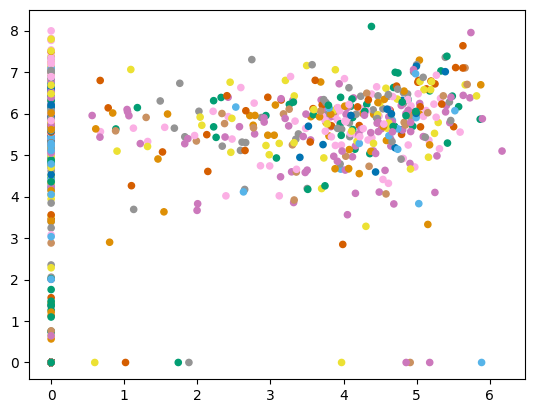

In [5]:
samples_per_cluster = min(1000000, cluster_data.max_samples // num_clusters)
num_samples = samples_per_cluster*num_clusters
(samples, cluster_labels) = cluster_data.get()#.sample(samples_per_cluster)
(fig, ax) = plt.subplots(1, 1)
plot_raw_data(samples[0][:1000, :2], cluster_labels[:1000], ax, colors)
plt.show()

### Train

In [6]:
(encoders, decoders, mappers, metrics) = train_model(samples, var_loss, num_modalities, modality_dims, latent_dims, 100)
outputs = get_outputs(samples, encoders, decoders, metrics, mappers, num_modalities)

# Plots

/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3548.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


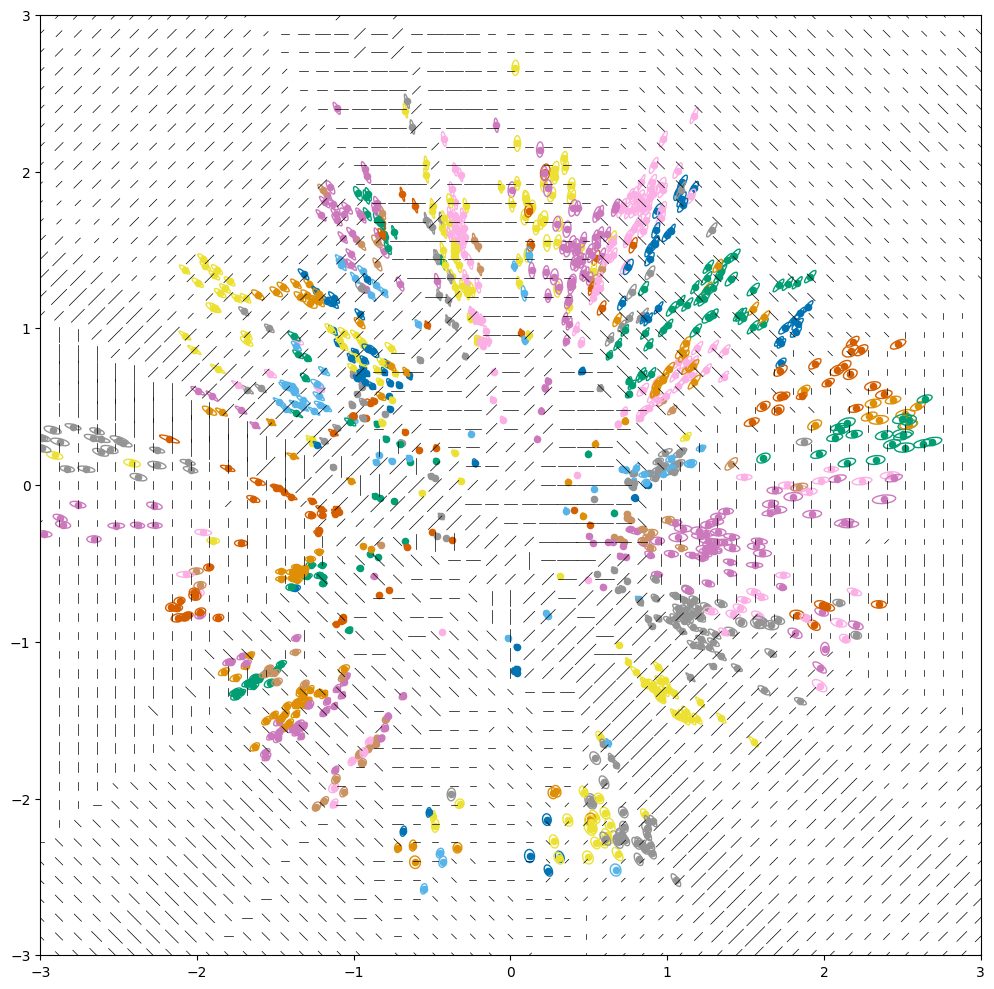

In [7]:
plot_types = ["latent"]
count = 1000
modal = 0

subset_orig = [modal_samples[::(num_samples//count)] for modal_samples in samples]
subset_recon = {key: arr[::(num_samples//count)] for (key, arr) in outputs["recons"].items()}
subset_labels = cluster_labels[::(num_samples//count)]
subset_means = outputs["means"][(modal, modal)][::(num_samples//count)]
subset_eigvals = outputs["eig_vals"][(modal, modal)][::(num_samples//count)]
subset_rotations = outputs["rotations"][(modal, modal)][::(num_samples//count)]

dim = modality_dims[0]
num_plots = len(plot_types)
fig = plt.figure(figsize = (10, 10))
if "orig" in plot_types:
    i = plot_types.index("orig")
    ax = fig.add_subplot(num_plots, 1, i+1, projection = "3d" if dim >= 3 else None)
    plot_raw_data(subset_orig[modal], subset_labels, ax, colors, marker_size = 10)
if "latent" in plot_types:
    i = plot_types.index("latent")
    ax = fig.add_subplot(num_plots, 1, i+1)
    plot_latent(subset_means, subset_labels, subset_eigvals, subset_rotations, ax,
                decoders[modal], colors)
if "recon" in plot_types:
    i = plot_types.index("recon")
    ax = fig.add_subplot(num_plots, 1, i+1, projection = "3d" if dim >= 3 else None)
    plot_recon_data(subset_orig[modal], subset_recon[(modal, modal)], ax, marker_size = 10)
plt.tight_layout()
# plt.savefig("toy_example_pipeline.png", bbox_inches = "tight")
plt.show()

# Trials

In [ ]:
import warnings
warnings.filterwarnings('ignore')

num_neighbors = 1000000
neighbor_scale = 5
num_steps = 10
cov_reg = 0.0
method = "medoid"
scoring = "rand"
distance = True
modal = 0
num_models = 0
trials = [(5000, 1)] #[(50, 100), (100, 100), (300, 100), (500, 10), (1000, 10), (2000, 5)]
metric_funcs = {"cov": get_cov_distance, "metric": get_riemann_distance, "jac": get_decoded_distance, 
                "hop": get_hop_distance, "eucl": get_euclidean_distance, }
batch_size = 32

results = {}
var_loss = VariationalLoss(num_modalities, recon_frac, cross_damp, within_var, cross_var)
try:
    for model_num in range(max(num_models, 1)):
        if num_models > 0:
            print("")
            (encoders, decoders, mappers, metrics) = train_model(samples, var_loss, num_modalities, modality_dims, latent_dims, 10)
            print("")
        for (count, num_trials) in trials:
            score_dict = {}
            for trial in range(num_trials):
                print(f"Running model {model_num} on {count} samples ({trial + 1}/{num_trials})             ", end = "\r")
                (trial_samples, trial_labels) = cluster_data.get()#.sample(count // num_clusters, seed = trial)
                trial_outputs = get_outputs(trial_samples, encoders, decoders, metrics, mappers, num_modalities)
                (trial_means, trial_transfs) = (trial_outputs["means"][(modal, modal)], trial_outputs["transfs"][(modal, modal)])
                # clusters = get_kmedoids(trial_means, metric_funcs, num_clusters, batch_size, distance,
                #                         z_transf = trial_transfs, num_steps = num_steps, decoder = decoders[modal], cov_reg = cov_reg,
                #                         num_neighbors = num_neighbors, neighbor_scale = neighbor_scale, metric = metrics[modal])
                clusters = get_agglomerated(trial_means, metric_funcs, num_clusters, batch_size, distance, num_neighbors = count // 10,
                                        z_transf = trial_transfs, num_steps = num_steps, decoder = decoders[modal], cov_reg = cov_reg,
                                        neighbor_scale = neighbor_scale, metric = metrics[modal])
                clusters["raw"] = KMeans(num_clusters, random_state = 42).fit_predict(trial_samples[modal])
                rand_scores = {method: adjusted_rand_score(trial_labels, pred_labels)
                            for (method, pred_labels) in clusters.items()}
                for (method, score) in rand_scores.items():
                    score_dict.setdefault(method, []).append(score)
            results.setdefault(count, {})[model_num] = {method: np.mean(scores) for (method, scores) in score_dict.items()}
except KeyboardInterrupt:
    pass

In [ ]:
(fig, axes) = plt.subplots(3, 2, figsize = (10, 15))
axes = axes.flatten()
for (ax, label_arr, name) in zip(axes, [subset_labels, *clusters.values()], ["true", *clusters.keys()]):
    plot_latent(subset_means, label_arr, None, None, ax, decoders[0], colors)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Rand Scores

## 3D Clusters, low variance

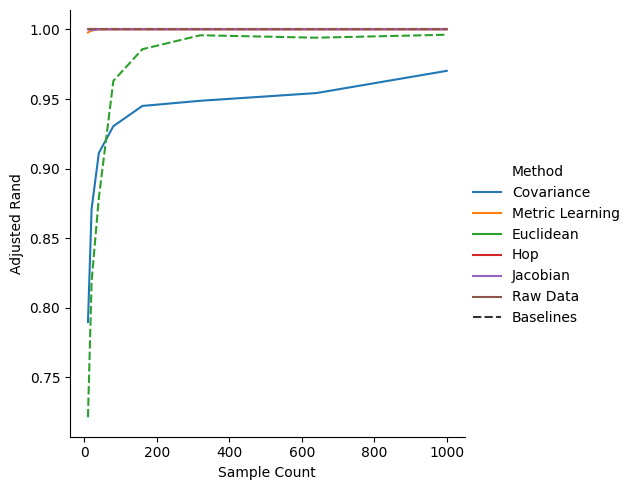

In [139]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

## 3D Clusters, high variance

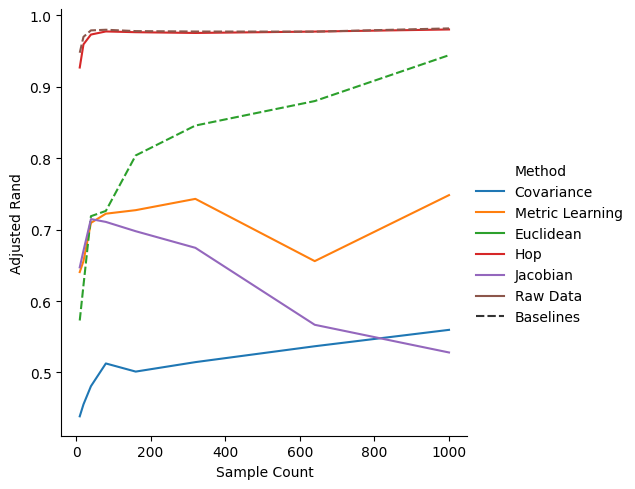

In [188]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

## 10D Clusters, low variance

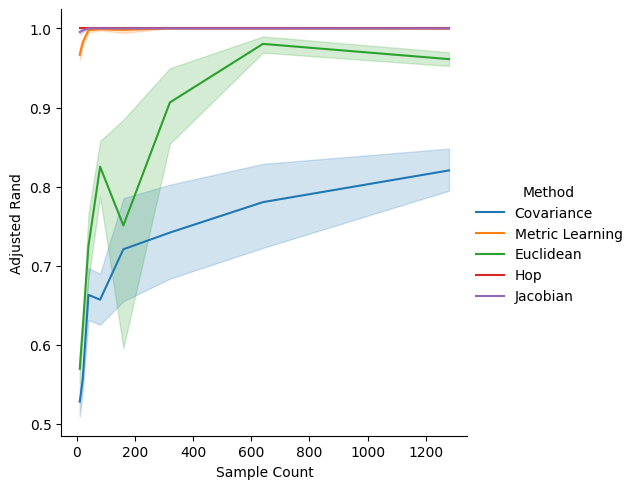

In [56]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line")
plt.show()

## 10D Cluster, high variance

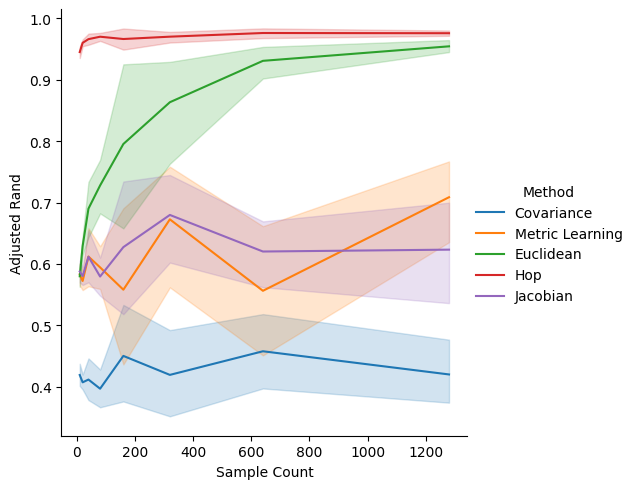

In [71]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line")
plt.show()

## Digits

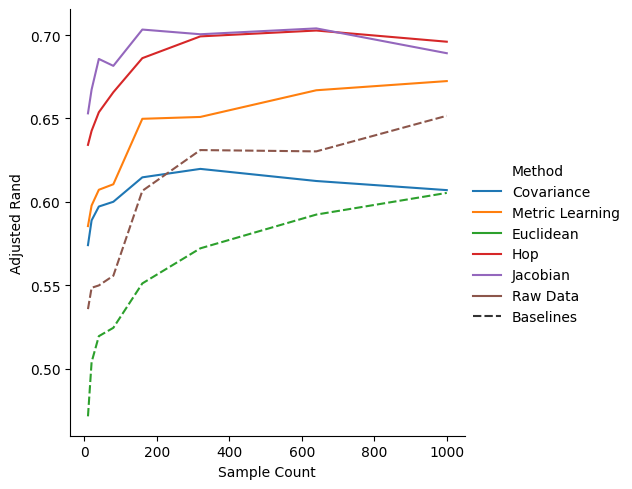

In [201]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

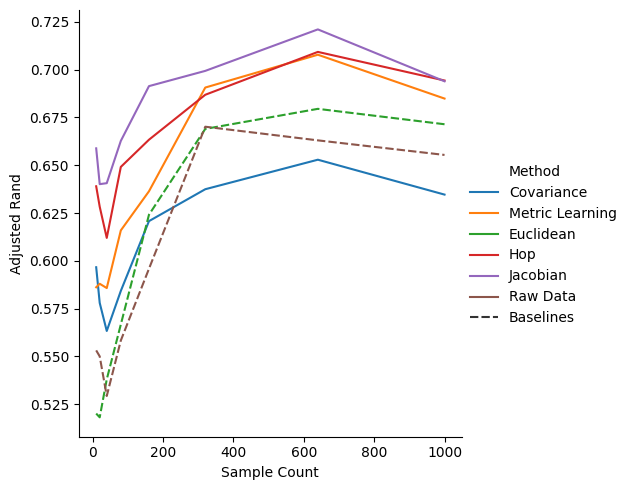

In [ ]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

## Fashion MNIST

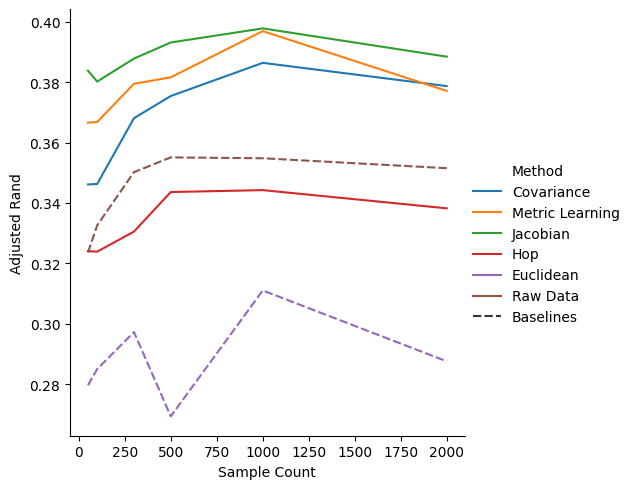

In [ ]:
#0.0
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

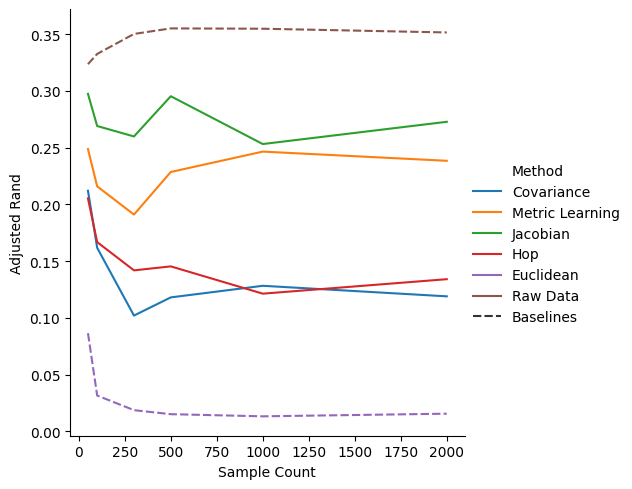

In [263]:
#0.0
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

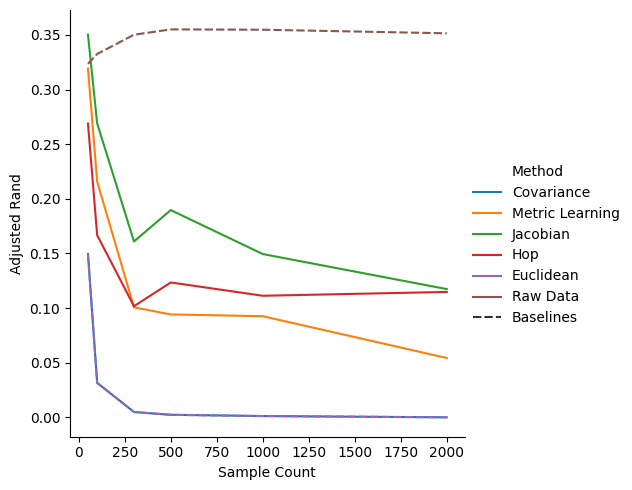

In [ ]:
#0.0
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

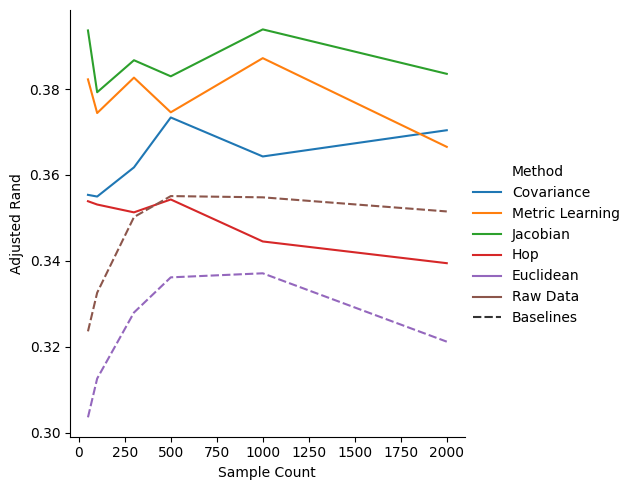

In [ ]:
#0.0
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

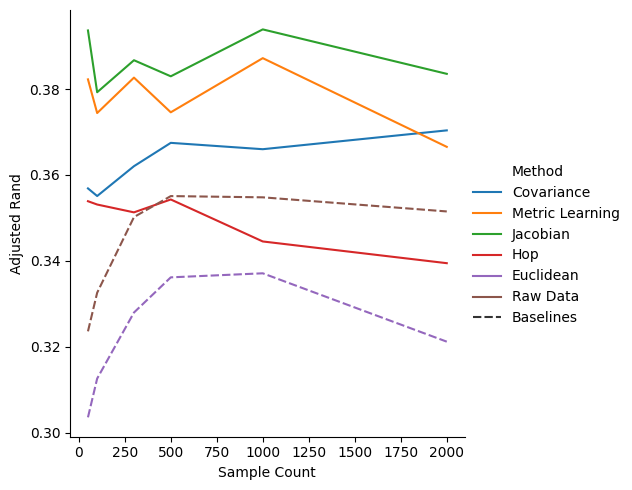

In [77]:
#0.0
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

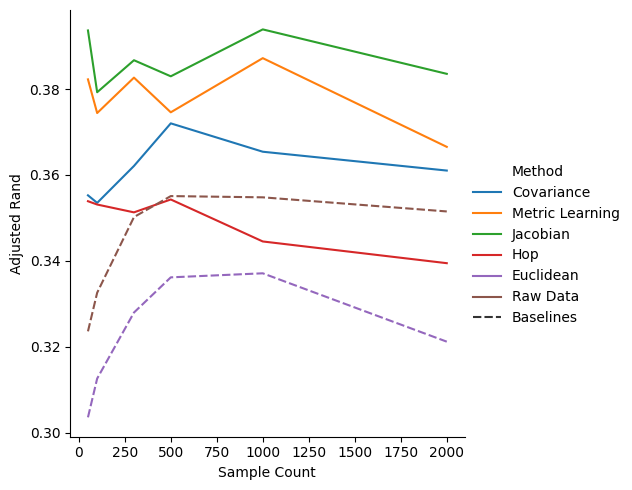

In [75]:
#1e-4
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

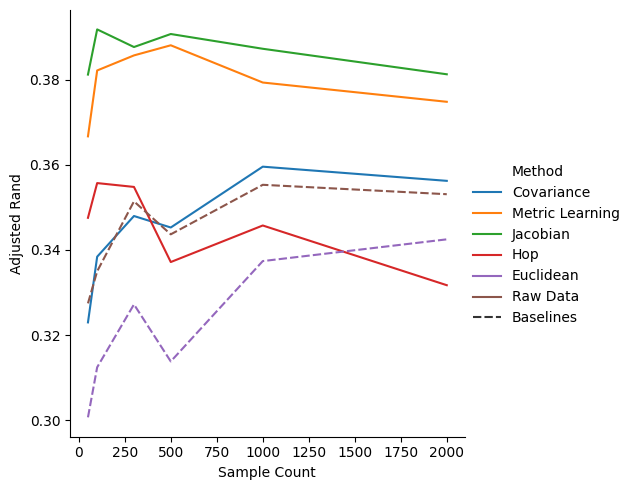

In [69]:
#1e-2
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

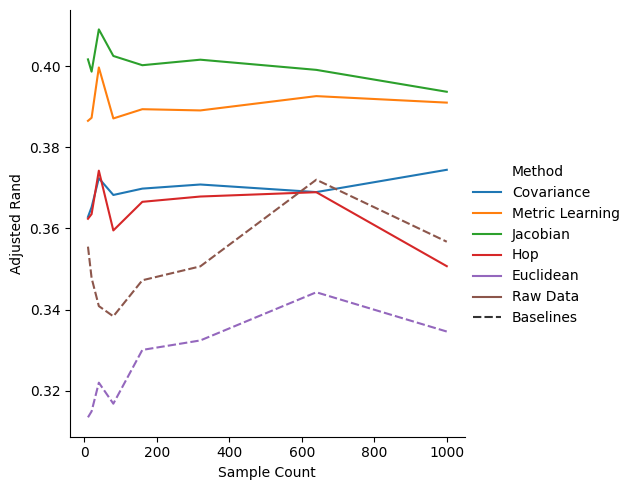

In [40]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

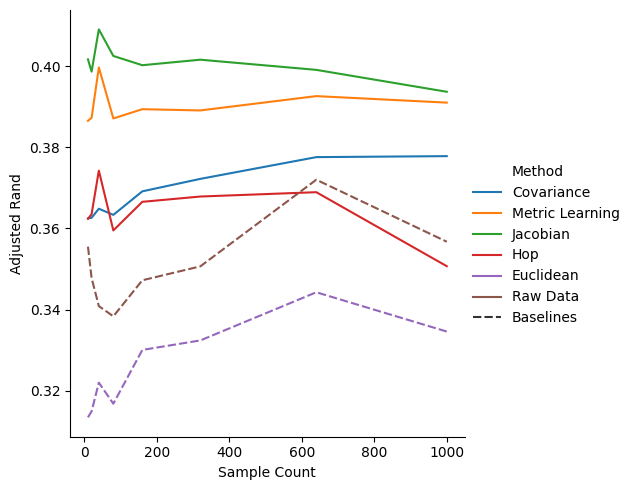

In [ ]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

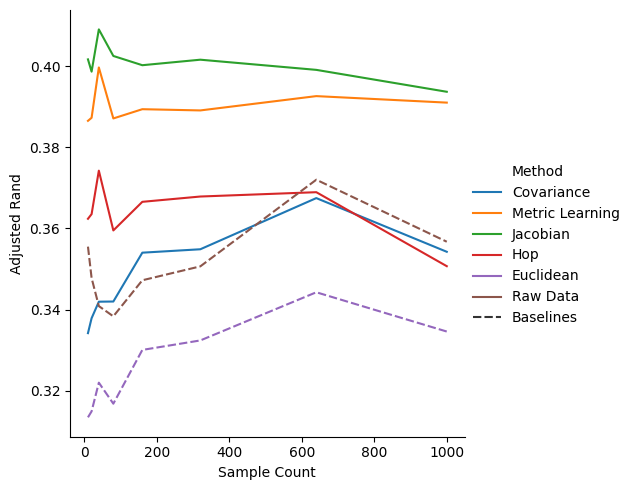

In [38]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

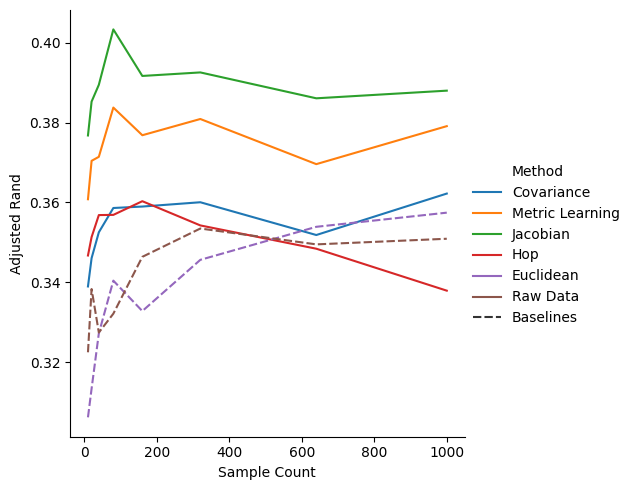

In [ ]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

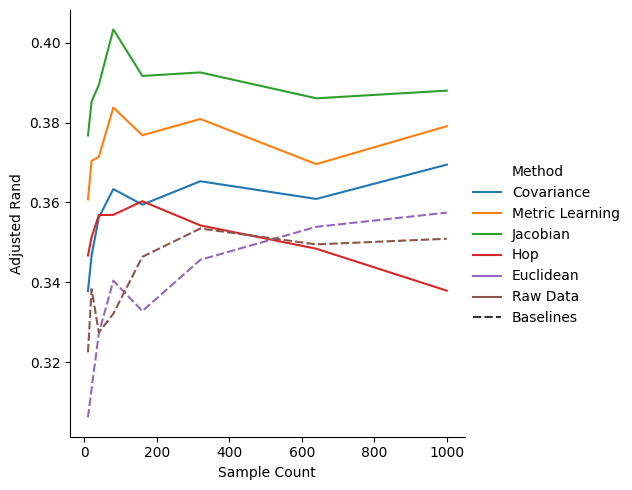

In [39]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

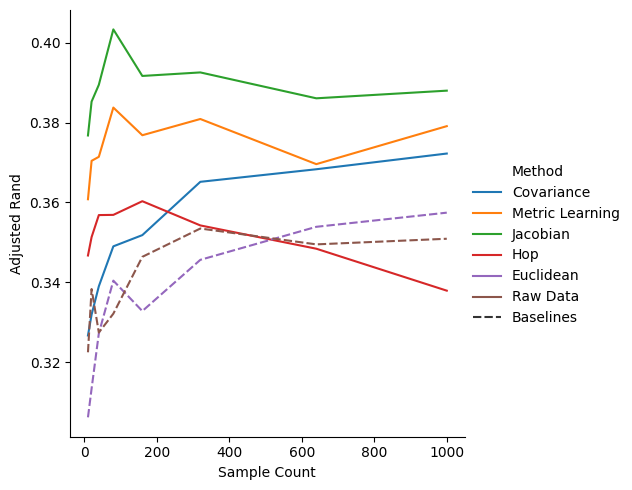

In [ ]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

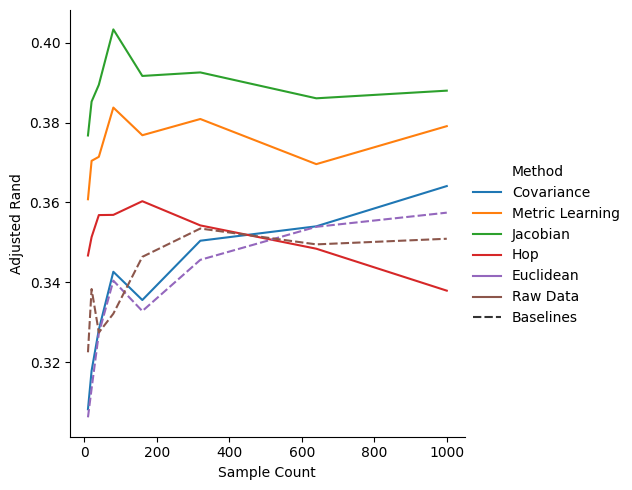

In [37]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (model_num, model_dict) in count_dict.items():
        for (method, rands) in model_dict.items():
            rands = [rands]
            plot_data["Sample Count"].extend([count]*len(rands))
            plot_data["Adjusted Rand"].extend(rands)
            plot_data["Method"].extend([method_names[method]]*len(rands))
            plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

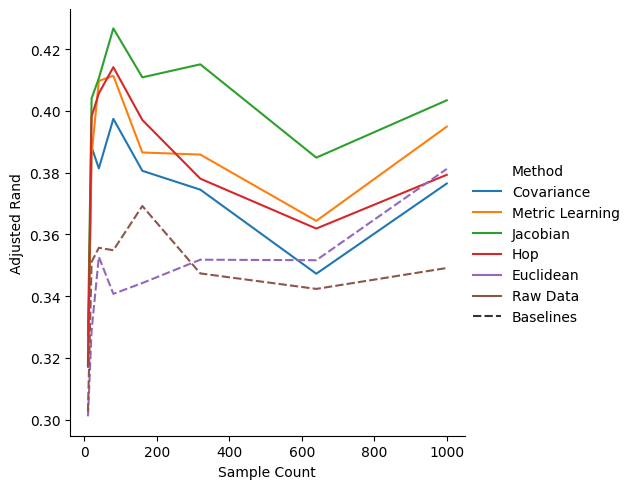

In [ ]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "raw": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "raw"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

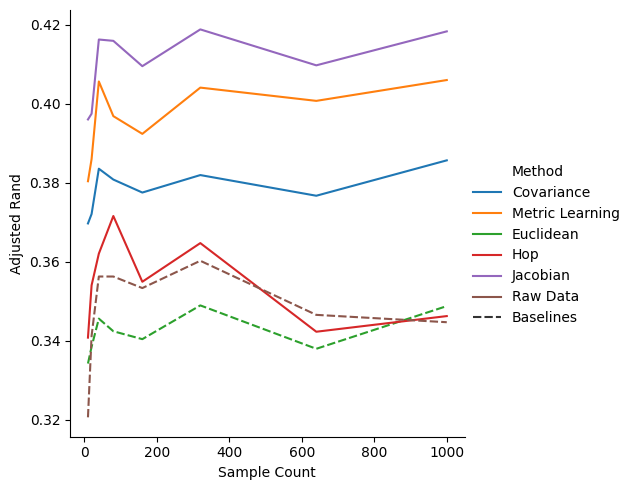

In [ ]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

## Patch-seq

#### All clusters

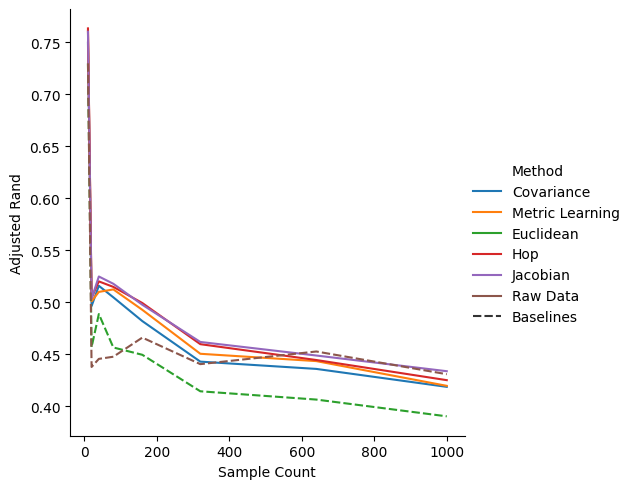

In [18]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

#### All clusters - Ephys

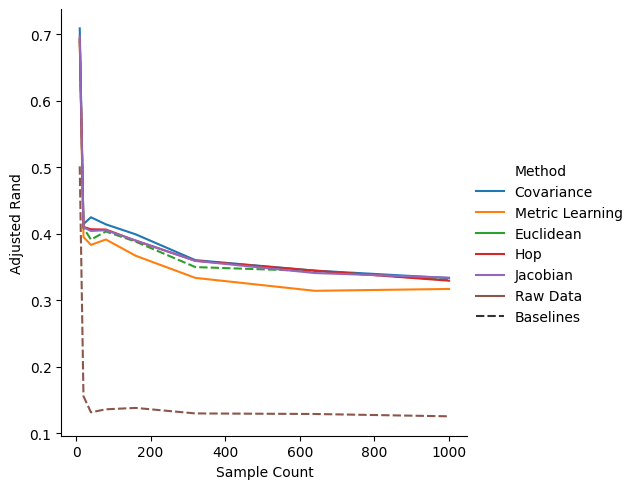

In [172]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

#### Two clusters

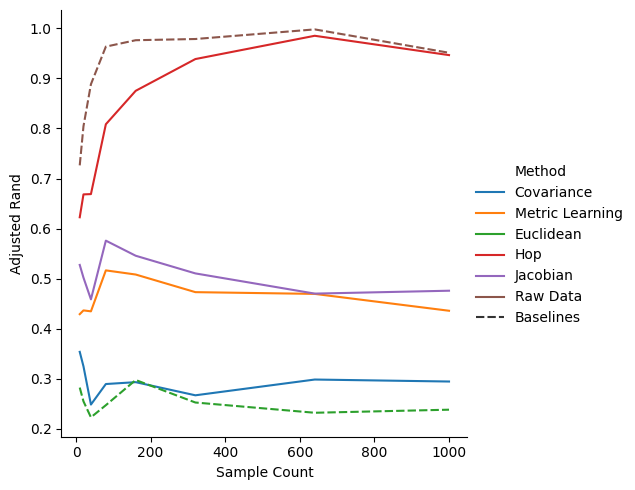

In [95]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

#### Merge 90

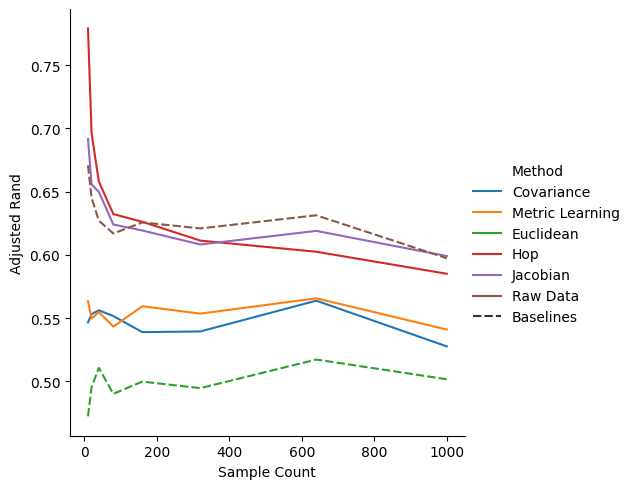

In [102]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

#### Merge 80

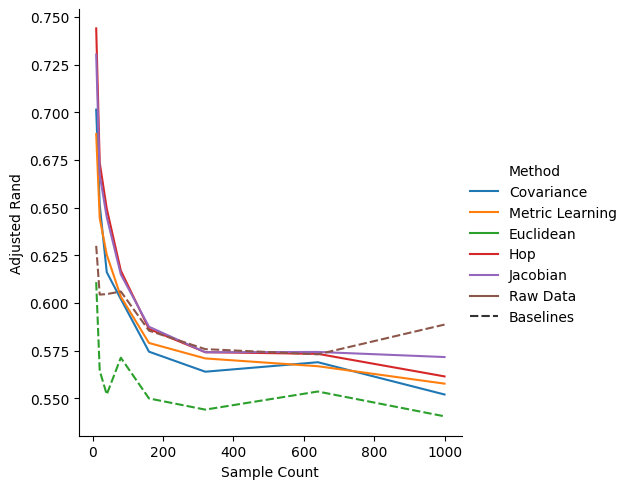

In [106]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

#### Merge 80 -- Ephys

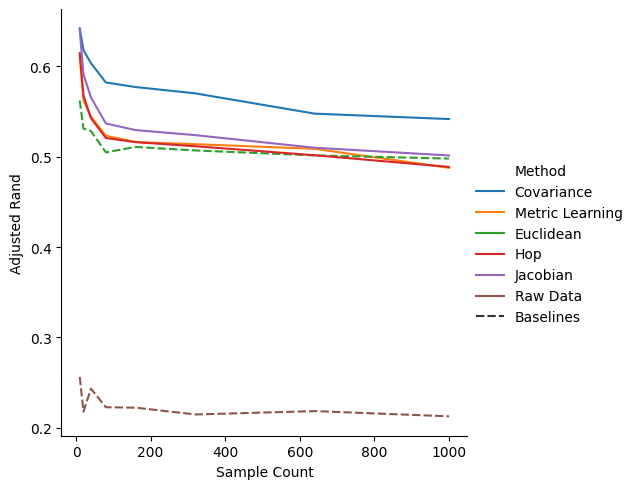

In [167]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

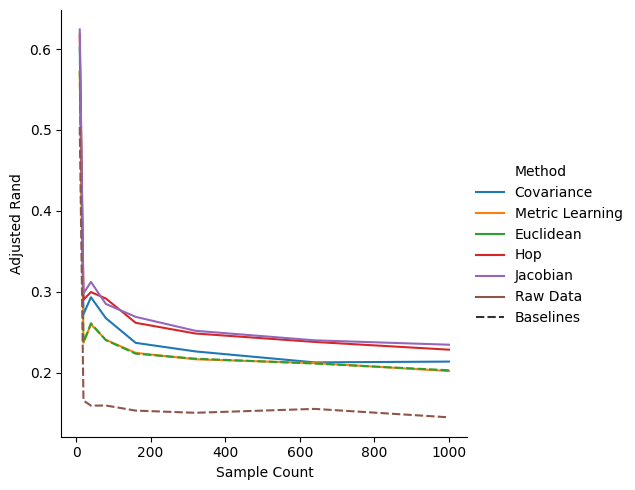

In [50]:
method_names = {"cov": "Covariance", "metric": "Metric Learning", "eucl": "Euclidean", "hop": "Hop", "jac": "Jacobian", "data": "Raw Data"}
plot_data = {"Sample Count": [], "Adjusted Rand": [], "Method": [], "_Style": []}
for (count, count_dict) in results.items():
    for (method, rands) in count_dict.items():
        plot_data["Sample Count"].extend([count]*len(rands))
        plot_data["Adjusted Rand"].extend(rands)
        plot_data["Method"].extend([method_names[method]]*len(rands))
        plot_data["_Style"].extend(["Baselines" if method in {"eucl", "data"} else "_solid"]*len(rands))
sns.relplot(data = plot_data, x = "Sample Count", y = "Adjusted Rand", hue = "Method", kind = "line", errorbar = None, style = "_Style")
plt.show()

# Metric Visualization

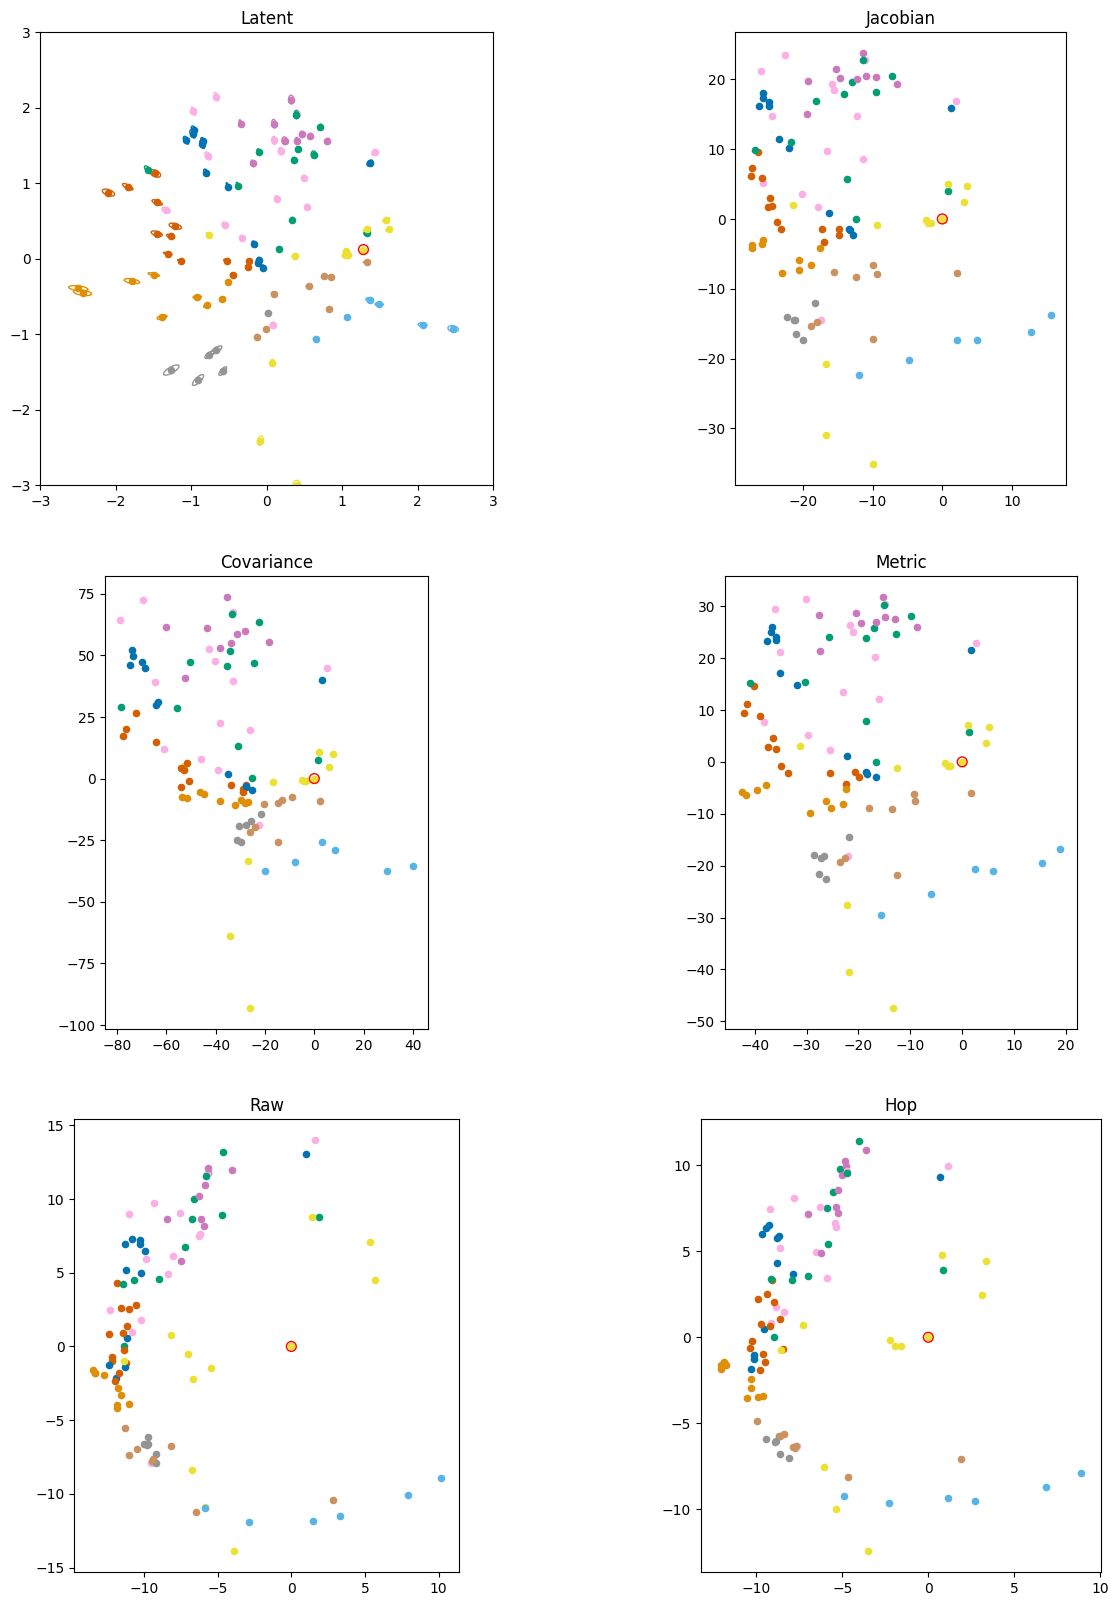

In [238]:
(means, eig_vals, rotations, transfs) = (outputs["means"][(0, 0)], outputs["eig_vals"][(0, 0)], outputs["rotations"][(0, 0)],
                                         outputs["transfs"][(0, 0)])
num = 100
eucl_dist = get_euclidean_distance(means, torch.arange(num), torch.arange(num))
cov_dist = get_cov_distance(means, transfs, 10, torch.arange(num), torch.arange(num)[None])
riemann_dist = get_riemann_distance(means, metrics[0], 10, torch.arange(num), torch.arange(num)[None])
decoded_dist = get_decoded_distance(means, decoders[0], 10, torch.arange(num), torch.arange(num)[None])
hop_dist = get_hop_distance(means, decoders[0], torch.arange(num), torch.arange(num)[None])
raw_dist = torch.square(samples[0][:num, None] - samples[0][None, :num]).sum(-1)**0.5

i = 3
(fig, axes) = plt.subplots(3, 2, figsize = (15, 20))
plot_latent(means[:num], cluster_labels[:num], eig_vals[:num], rotations[:num], axes[0, 0], None, colors)
axes[0, 0].scatter(*means[i], s = 50, facecolors = "none", edgecolors = "r")
axes[0, 0].set_title("Latent")
for (dist, ax, name) in [(raw_dist, axes[2, 0], "Raw"), (cov_dist, axes[1, 0], "Covariance"), (riemann_dist, axes[1, 1], "Metric"),
                         (decoded_dist, axes[0, 1], "Jacobian"), (hop_dist, axes[2, 1], "Hop")]:
    centered_means = means[:num] - means[:num][i:i+1]
    normed_means = centered_means / torch.linalg.norm(centered_means, dim = -1, keepdim = True)
    scaled_means = torch.nan_to_num(normed_means*dist[i][:, None])
    plot_latent(scaled_means, cluster_labels[:num], eig_vals[:num], rotations[:num], ax, None, colors, (None, None))
    ax.set_aspect("equal")
    ax.set_title(name)
    ax.scatter([0], [0], s = 50, facecolors = "none", edgecolors = "r")
plt.show()

# Eccentricity

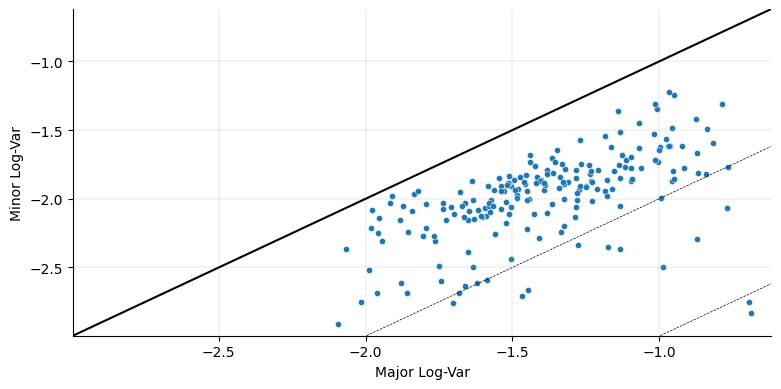

In [332]:
plot = sns.relplot(
    data = {"Major Log-Var": np.log10(subset_metric_eigvals[:, 1]), "Minor Log-Var": np.log10(subset_metric_eigvals[:, 0])}, 
    x = "Major Log-Var", y = "Minor Log-Var", s = 20, height = 4, aspect = 2)
ex_ax = plot.axes[0][0]
ax_lims = (min(ex_ax.get_xlim()[0], ex_ax.get_ylim()[0]), max(ex_ax.get_xlim()[1], ex_ax.get_ylim()[1]))
ax = ex_ax
(min_lim, max_lim) = ax_lims
ax.set_xlim(min_lim, max_lim)
ax.set_ylim(min_lim, max_lim)
ax.plot([min_lim, max_lim], [min_lim, max_lim], color = "black")
ax.plot([min_lim + 1, max_lim + 1], [min_lim, max_lim], color = "black", linestyle = "dashed", linewidth = 0.5)
ax.plot([min_lim + 2, max_lim + 2], [min_lim, max_lim], color = "black", linestyle = "dashed", linewidth = 0.5)
ax.plot([min_lim + 3, max_lim + 3], [min_lim, max_lim], color = "black", linestyle = "dashed", linewidth = 0.5)
ax.grid(linewidth = 0.2)
ax.tick_params(labelbottom = True, labelleft = True)
plt.savefig("figs/eccentric_stats.png", bbox_inches = "tight")
plt.show()

# Manifold Warping

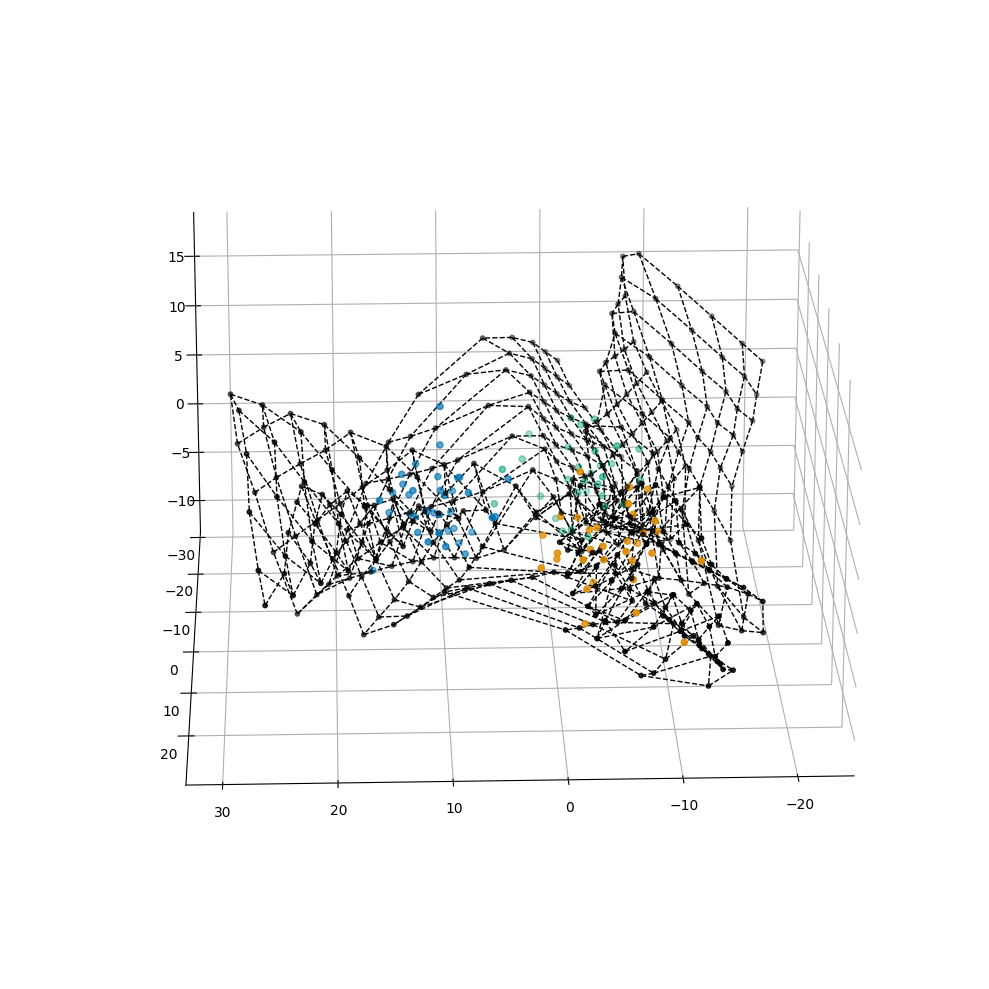

In [186]:
num_points = 20

indices = np.random.choice(num_samples, [100], replace = False)
subset_labels = cluster_labels[indices]
subsamples = samples[0][indices]

fig = plt.figure(figsize = (20, 10))
# ax_latent = fig.add_subplot(121)
ax_recon = fig.add_subplot(111, projection = "3d")
grid_points = np.linspace(-3.5, 3.5, num_points)
mesh = np.stack(np.meshgrid(grid_points, grid_points), -1)
mesh_recon = decoders[0](torch.from_numpy(mesh).flatten(0, 1).float()).unflatten(0, mesh.shape[:2]).numpy(force = True)

def init():
    mesh_recon_flat = mesh_recon.reshape([-1, 3])
    ax_recon.scatter(subsamples[:, 0], subsamples[:, 1], subsamples[:, 2], c = np.asarray(colors)[subset_labels])
    ax_recon.scatter(mesh_recon_flat[:, 0], mesh_recon_flat[:, 1], mesh_recon_flat[:, 2], s = 10, c = "black")
    col_recon_nn = np.stack([mesh_recon[:, 1:], mesh_recon[:, :-1]], -2).reshape([-1, 2, 3])
    row_recon_nn = np.stack([mesh_recon[1:], mesh_recon[:-1]], -2).reshape([-1, 2, 3])
    for coords in col_recon_nn:
        ax_recon.plot(coords[:, 0], coords[:, 1], coords[:, 2], color = "black", linestyle = "dashed", linewidth = 1)
    for coords in row_recon_nn:
        ax_recon.plot(coords[:, 0], coords[:, 1], coords[:, 2], color = "black", linestyle = "dashed", linewidth = 1)
    # ax_recon.plot(row_recon_nn[..., 0].T, row_recon_nn[..., 1].T, row_recon_nn[..., 2].T, color = "black", linestyle = "dashed")
    # ax_recon.plot(col_recon_nn[..., 0].T, col_recon_nn[..., 1].T, col_recon_nn[..., 2].T, color = "black", linestyle = "dashed")

    # ax_recon.set_xticklabels([])
    # ax_recon.set_yticklabels([])
    # ax_recon.set_zticklabels([])
    ax_recon.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.set_aspect("equal")
    # ax_recon.set_ylim(-11, -7)
    # ax_recon.set_xlim(-8, -3)
    # ax_recon.set_zlim(-1.5, 1.5)
    ax_recon.view_init(elev = 20)
    plt.tight_layout()

def update(frame):
    ax_recon.view_init(elev = 20, azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450, 2), init_func = init)
writer = pltanim.PillowWriter(fps = 10)
animation.save(f"test.gif", writer = writer)
plt.show()

# Manifold Tracing

In [1187]:
chosen = [39, 0, 47]
ranges = ((-2.0, 0.0), (0.5, 1.5))

In [1141]:
indices = np.random.choice(num_samples, [100], replace = False)

subset_labels = cluster_labels[indices]
subset_means = means[(0, 0)][indices]
subset_transf = transfs[(0, 0)][indices]
subset_eigvals = eig_vals[(0, 0)][indices]
subset_rotations = rotations[(0, 0)][indices]
subset_recons = recons[(0, 0)][indices]
subsamples = samples[0][indices]
subset_colors = np.asarray(colors)[subset_labels]

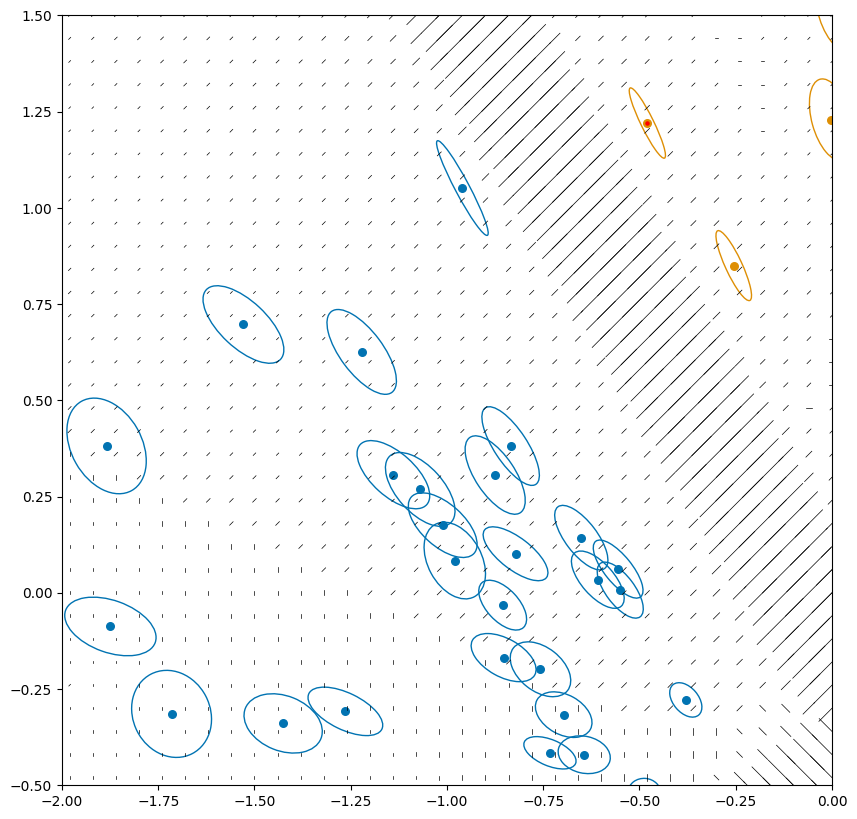

In [1161]:
fig = plt.figure(figsize = (10, 10))
ax_latent = fig.add_subplot(111)
(z_grid, gradients) = plot_gradient(ax_latent, decoders[0], grad_range = [(-3, 3), (-3, 3)], grid_points = 100)
for ((x, y), (min_eig, max_eig), angle, color_index) in zip(subset_means, subset_eigvals, subset_rotations, subset_labels):
    color = colors[color_index]
    ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
    ax_latent.add_patch(ellipse)
    ax_latent.scatter([x], [y], s = 30, color = color)
ax_latent.scatter(*subset_means[chosen[2]], s = 5, color = "red")
ax_latent.set_aspect(1)
ax_latent.set_xlim(*ranges[0])
ax_latent.set_ylim(*ranges[1])
plt.show()

In [1157]:
torch.argsort(torch.square(subset_means - torch.as_tensor([-0.5, 1.25])).sum(-1), -1)

tensor([47, 86, 88, 39, 27, 37, 13, 55, 98, 59, 67, 12, 79, 69, 63, 64, 56, 61,
        82,  0, 38, 91, 48, 32, 42, 20, 50, 77, 34, 75,  5, 92, 35, 11, 25, 85,
        54, 53, 84, 97, 66, 76, 29, 26, 80, 81, 15, 40, 19, 89, 72, 17, 43, 87,
        44, 95, 23,  8, 65, 51, 94,  6, 30,  2, 18, 24, 83, 68, 22, 60, 10, 36,
        16, 45, 99, 73,  4, 49, 33, 52, 71, 93, 46,  7,  9, 41, 90, 96,  3, 57,
        70, 78, 74, 14, 28, 58, 62, 31, 21,  1])

## Approach 1

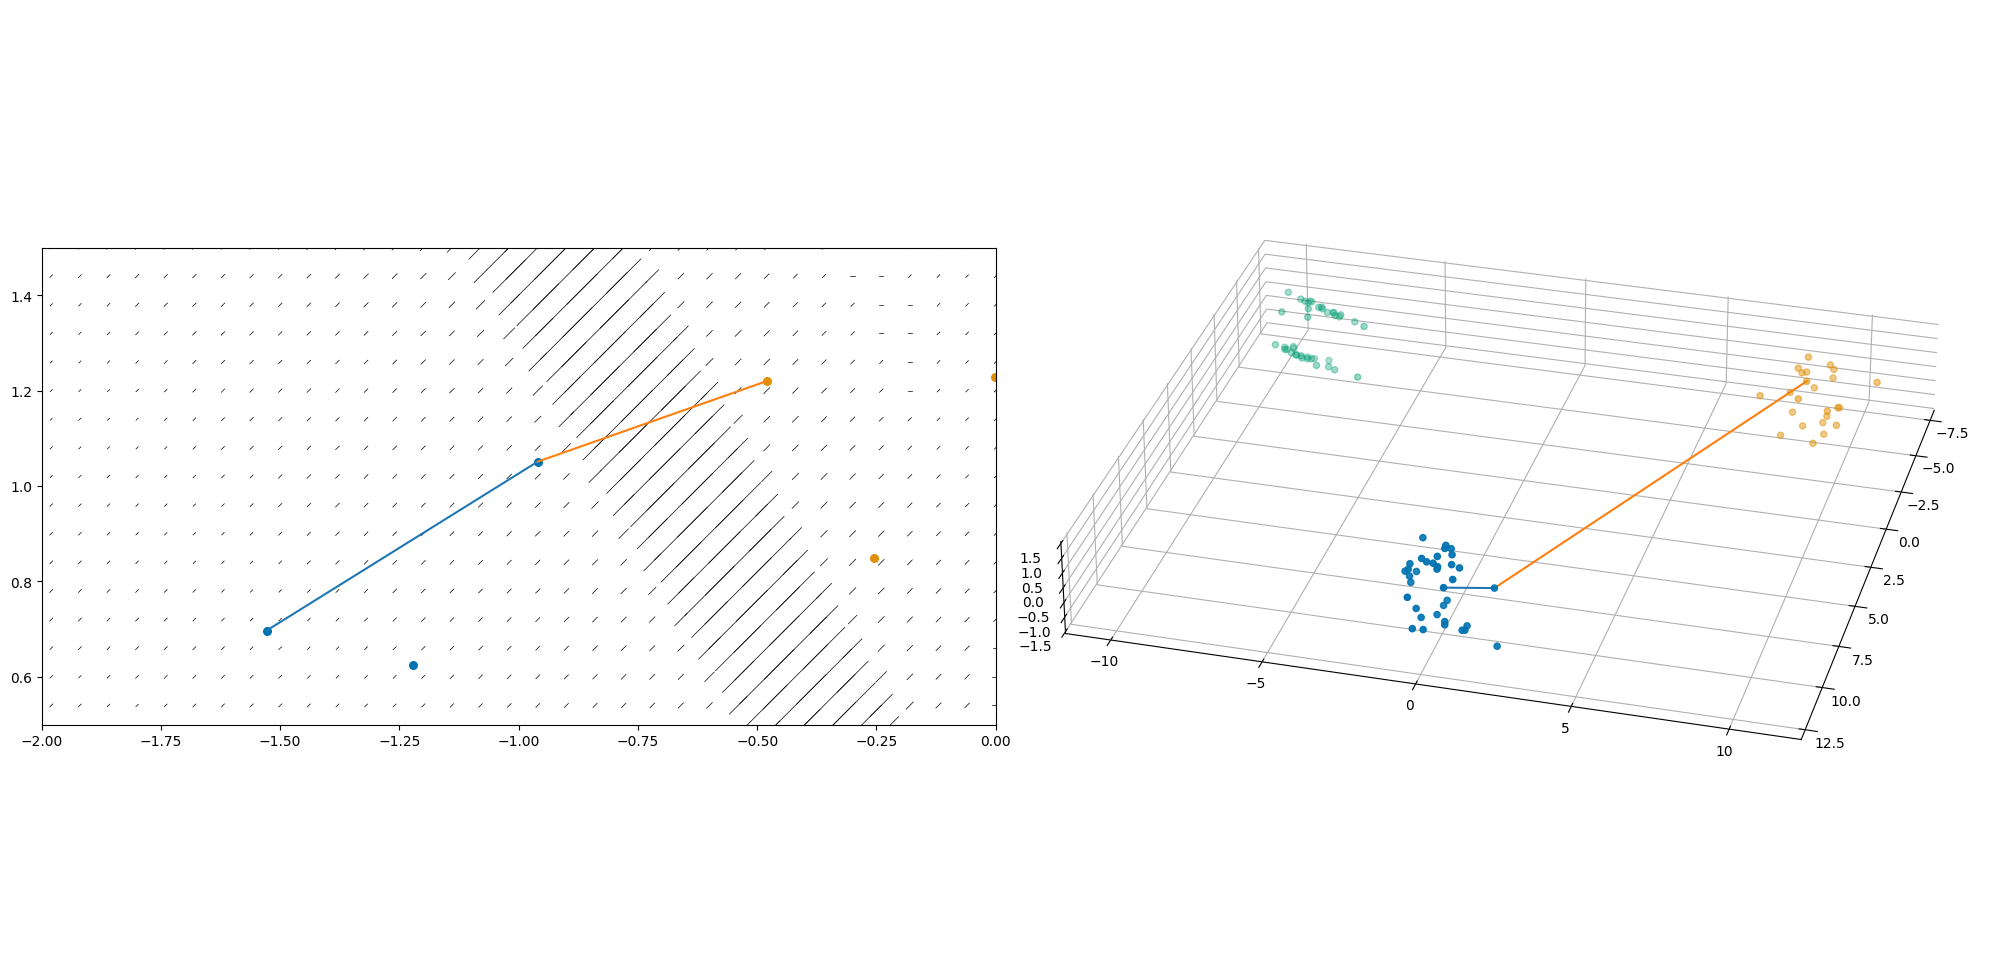

Same: 2.132814645767212
Different: 15.132770538330078


In [1201]:
fig = plt.figure(figsize = (20, 10))
ax_latent = fig.add_subplot(121)
ax_recon = fig.add_subplot(122, projection = "3d")

def init():
    (z_grid, gradients) = plot_gradient(ax_latent, decoders[0], grad_range = [(-3, 3), (-3, 3)], grid_points = 100)
    for ((x, y), (min_eig, max_eig), angle, color_index) in zip(subset_means, subset_eigvals, subset_rotations, subset_labels):
        color = colors[color_index]
        # ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
        # ax_latent.add_patch(ellipse)
        ax_latent.scatter([x], [y], s = 30, color = color)
    ax_latent.set_aspect(1)
    ax_latent.set_xlim(*ranges[0])
    ax_latent.set_ylim(*ranges[1])
    ax_latent.plot([subset_means[chosen[0], 0], subset_means[chosen[1], 0]], [subset_means[chosen[0], 1], subset_means[chosen[1], 1]])
    ax_latent.plot([subset_means[chosen[0], 0], subset_means[chosen[2], 0]], [subset_means[chosen[0], 1], subset_means[chosen[2], 1]])

    ax_recon.scatter(subset_recons[:, 0], subset_recons[:, 1], subset_recons[:, 2], c = np.asarray(colors)[subset_labels])
    ax_recon.plot([subset_recons[chosen[0], 0], subset_recons[chosen[1], 0]], [subset_recons[chosen[0], 1], subset_recons[chosen[1], 1]], [subset_recons[chosen[0], 2], subset_recons[chosen[1], 2]])
    ax_recon.plot([subset_recons[chosen[0], 0], subset_recons[chosen[2], 0]], [subset_recons[chosen[0], 1], subset_recons[chosen[2], 1]], [subset_recons[chosen[0], 2], subset_recons[chosen[2], 2]])
    # ax_recon.set_xticklabels([])
    # ax_recon.set_yticklabels([])
    # ax_recon.set_zticklabels([])
    ax_recon.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.set_aspect("equal")
    # ax_recon.set_ylim(-11, -7)
    # ax_recon.set_xlim(-8, -3)
    ax_recon.set_zlim(-1.5, 1.5)
    ax_recon.view_init(elev = 30, azim = 15)
    plt.tight_layout()

def update(frame):
    pass

animation = pltanim.FuncAnimation(fig, update, np.arange(1), init_func = init)
writer = pltanim.PillowWriter(fps = 1)
animation.save(f"test.gif", writer = writer)
plt.show()
print(f"Same: {np.linalg.norm(subset_recons[chosen[0]] - subset_recons[chosen[1]])}")
print(f"Different: {np.linalg.norm(subset_recons[chosen[0]] - subset_recons[chosen[2]])}")

## Approach 2

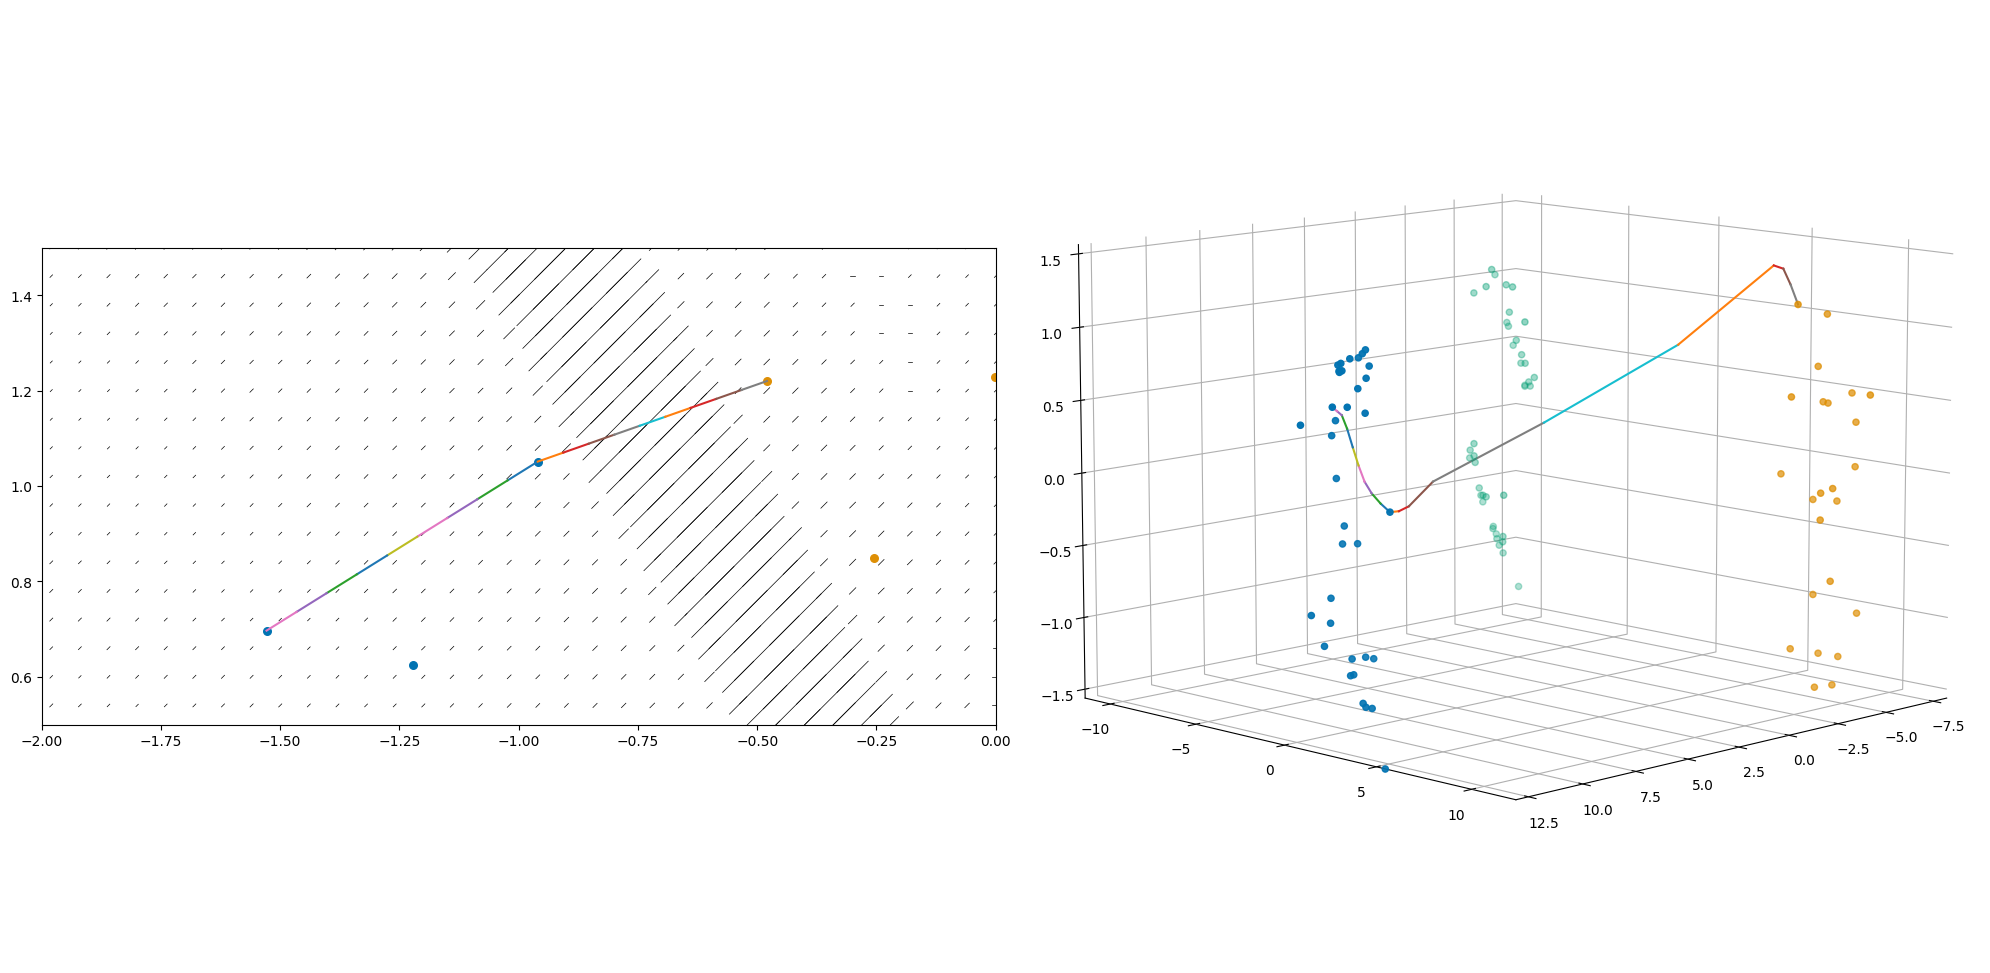

In [1189]:
fig = plt.figure(figsize = (20, 10))
ax_latent = fig.add_subplot(121)
ax_recon = fig.add_subplot(122, projection = "3d")

((x_0, y_0), (x_s, y_s), (x_d, y_d)) = (subset_means[chosen[0]], subset_means[chosen[1]], subset_means[chosen[2]])
steps_same = np.stack([np.linspace(x_0, x_s, 10), np.linspace(y_0, y_s, 10)], -1)
steps_diff = np.stack([np.linspace(x_0, x_d, 10), np.linspace(y_0, y_d, 10)], -1)
steps_same_recon = decoders[0](torch.from_numpy(steps_same).float()).numpy(force = True)
steps_diff_recon = decoders[0](torch.from_numpy(steps_diff).float()).numpy(force = True)

def init():
    (z_grid, gradients) = plot_gradient(ax_latent, decoders[0], grad_range = [(-3, 3), (-3, 3)], grid_points = 100)
    for ((x, y), (min_eig, max_eig), angle, color_index) in zip(subset_means, subset_eigvals, subset_rotations, subset_labels):
        color = colors[color_index]
        # ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
        # ax_latent.add_patch(ellipse)
        ax_latent.scatter([x], [y], s = 30, color = color)
    ax_latent.set_aspect(1)
    ax_latent.set_xlim(*ranges[0])
    ax_latent.set_ylim(*ranges[1])

    ax_recon.scatter(subset_recons[:, 0], subset_recons[:, 1], subset_recons[:, 2], c = np.asarray(colors)[subset_labels])
    # ax_recon.set_xticklabels([])
    # ax_recon.set_yticklabels([])
    # ax_recon.set_zticklabels([])
    ax_recon.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax_recon.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    # ax_recon.set_aspect("equal")
    # ax_recon.set_ylim(-5, 5)
    # ax_recon.set_xlim(-8, -3)
    ax_recon.set_zlim(-1.5, 1.5)
    ax_recon.view_init(elev = 10, azim = 45)
    plt.tight_layout()

def update(frame):
    ((x_s_0, y_s_0), (x_s_1, y_s_1)) = (steps_same[frame - 1], steps_same[frame])
    ((x_d_0, y_d_0), (x_d_1, y_d_1)) = (steps_diff[frame - 1], steps_diff[frame])
    ((x_s_0_recon, y_s_0_recon, z_s_0_recon), (x_s_1_recon, y_s_1_recon, z_s_1_recon)) = (steps_same_recon[frame - 1], steps_same_recon[frame])
    ((x_d_0_recon, y_d_0_recon, z_d_0_recon), (x_d_1_recon, y_d_1_recon, z_d_1_recon)) = (steps_diff_recon[frame - 1], steps_diff_recon[frame])
    ax_latent.plot([x_s_0, x_s_1], [y_s_0, y_s_1])
    ax_latent.plot([x_d_0, x_d_1], [y_d_0, y_d_1])
    ax_recon.plot([x_s_0_recon, x_s_1_recon], [y_s_0_recon, y_s_1_recon], [z_s_0_recon, z_s_1_recon])
    ax_recon.plot([x_d_0_recon, x_d_1_recon], [y_d_0_recon, y_d_1_recon], [z_d_0_recon, z_d_1_recon])

animation = pltanim.FuncAnimation(fig, update, np.arange(1, 10), init_func = init)
writer = pltanim.PillowWriter(fps = 1)
animation.save(f"test.gif", writer = writer)
plt.show()

## Approach 3

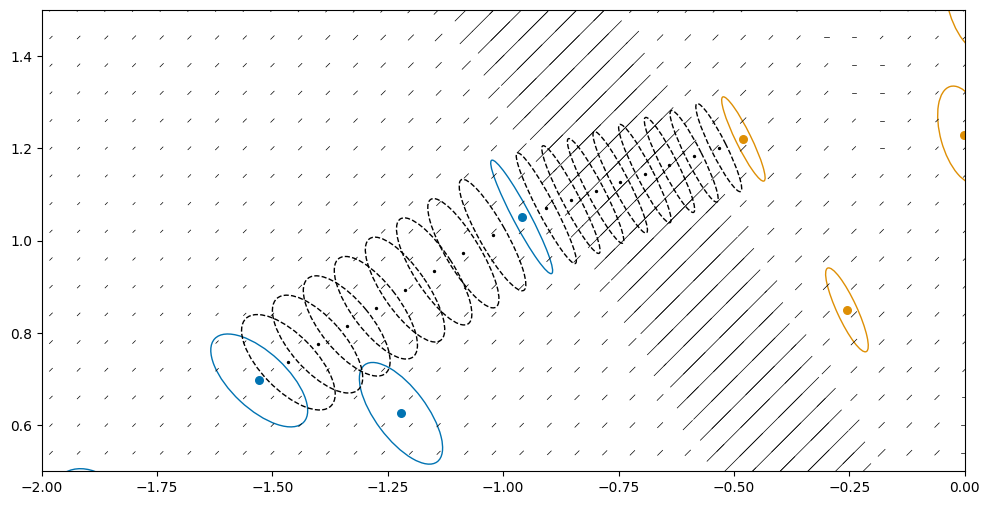

In [1195]:
fig = plt.figure(figsize = (10, 10))
ax_latent = fig.add_subplot(111)
steps = np.linspace(0, 1, 10)[1:-1, None, None]

start_cov = np.einsum("ij,kj->ik", subset_transf[chosen[0]], subset_transf[chosen[0]])
same_cov = np.einsum("ij,kj->ik", subset_transf[chosen[1]], subset_transf[chosen[1]])
diff_cov = np.einsum("ij,kj->ik", subset_transf[chosen[2]], subset_transf[chosen[2]])

same_interp = (1 - steps)*start_cov[None] + steps*same_cov[None]
diff_interp = (1 - steps)*start_cov[None] + steps*diff_cov[None]
(same_vals, same_vecs) = np.linalg.eigh(same_interp)
same_rots = 180*np.arccos(same_vecs[:, 1, 0])/np.pi
(diff_vals, diff_vecs) = np.linalg.eigh(diff_interp)
diff_rots = 180*np.arccos(diff_vecs[:, 1, 0])/np.pi

((x_0, y_0), (x_s, y_s), (x_d, y_d)) = (subset_means[chosen[0]], subset_means[chosen[1]], subset_means[chosen[2]])
steps_same = np.stack([np.linspace(x_0, x_s, 10), np.linspace(y_0, y_s, 10)], -1)[1:-1]
steps_diff = np.stack([np.linspace(x_0, x_d, 10), np.linspace(y_0, y_d, 10)], -1)[1:-1]

def init():
    (z_grid, gradients) = plot_gradient(ax_latent, decoders[0], grad_range = [(-3, 3), (-3, 3)], grid_points = 100)
    for ((x, y), (min_eig, max_eig), angle, color_index) in zip(subset_means, subset_eigvals, subset_rotations, subset_labels):
        color = colors[color_index]
        ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
        ax_latent.add_patch(ellipse)
        ax_latent.scatter([x], [y], s = 30, color = color)
    for ((min_eig, max_eig), angle, (x_step, y_step)) in zip(same_vals, same_rots, steps_same):
        ellipse = Ellipse(xy = (x_step, y_step), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = "black", fc = 'None', lw = 1,
                          linestyle = "dashed")
        ax_latent.add_patch(ellipse)
        ax_latent.scatter([x_step], [y_step], s = 2, color = "black")
    for ((min_eig, max_eig), angle, (x_step, y_step)) in zip(diff_vals, diff_rots, steps_diff):
        ellipse = Ellipse(xy = (x_step, y_step), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = "black", fc = 'None', lw = 1,
                          linestyle = "dashed")
        ax_latent.add_patch(ellipse)
        ax_latent.scatter([x_step], [y_step], s = 2, color = "black")
    ax_latent.set_aspect(1)
    ax_latent.set_xlim(*ranges[0])
    ax_latent.set_ylim(*ranges[1])
    plt.tight_layout()

def update(frame):
    pass

animation = pltanim.FuncAnimation(fig, update, np.arange(1, 2), init_func = init)
writer = pltanim.PillowWriter(fps = 1)
animation.save(f"test.gif", writer = writer)
plt.show()

## Approach 4

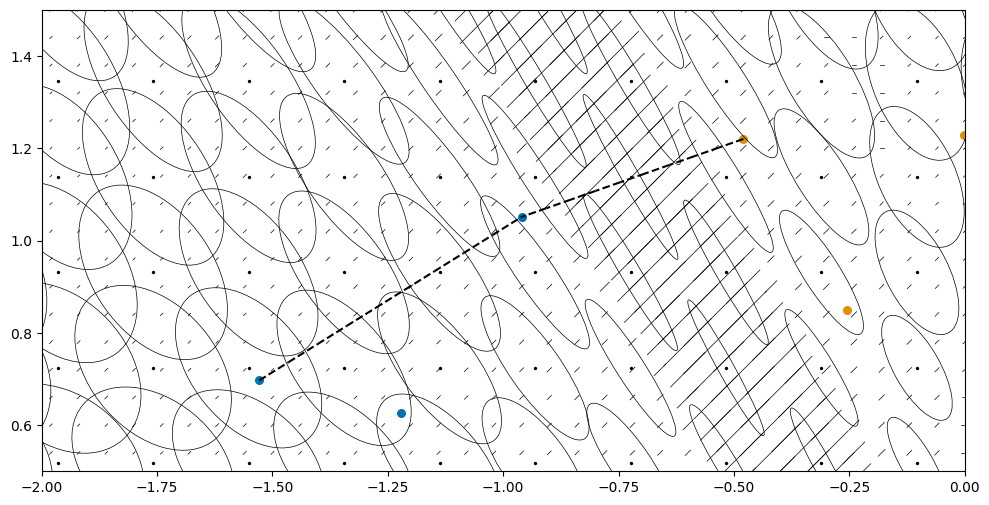

In [1199]:
fig = plt.figure(figsize = (10, 10))
ax_latent = fig.add_subplot(111)
steps = np.linspace(0, 1, 10)[:, None, None]

grid_points = np.linspace(-3.0, 3.0, 30)
mesh = np.stack(np.meshgrid(grid_points, grid_points), -1).reshape([-1, 2])
mesh_transf = metrics[0](torch.from_numpy(mesh).float()).numpy(force = True)
mesh_covs = np.einsum("nij,nkj->nik", mesh_transf, mesh_transf)
(mesh_vals, mesh_vecs) = np.linalg.eigh(mesh_covs)
mesh_rots = 180*np.arccos(mesh_vecs[:, 1, 0])/np.pi

((x_0, y_0), (x_s, y_s), (x_d, y_d)) = (subset_means[chosen[0]], subset_means[chosen[1]], subset_means[chosen[2]])
steps_same = np.stack([np.linspace(x_0, x_s, 10), np.linspace(y_0, y_s, 10)], -1)
steps_diff = np.stack([np.linspace(x_0, x_d, 10), np.linspace(y_0, y_d, 10)], -1)

def init():
    (z_grid, gradients) = plot_gradient(ax_latent, decoders[0], grad_range = [(-3, 3), (-3, 3)], grid_points = 100)
    for ((x, y), (min_eig, max_eig), angle, color_index) in zip(subset_means, subset_eigvals, subset_rotations, subset_labels):
        color = colors[color_index]
        ax_latent.scatter([x], [y], s = 30, color = color)
    for ((min_eig, max_eig), angle, (x_step, y_step)) in zip(mesh_vals, mesh_rots, mesh):
        ellipse = Ellipse(xy = (x_step, y_step), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = "black", fc = 'None', lw = 0.5)
        ax_latent.add_patch(ellipse)
        ax_latent.scatter([x_step], [y_step], s = 2, color = "black")
    for ((x_s, y_s), (x_prev, y_prev)) in zip(steps_same[1:], steps_same[:-1]):
        ax_latent.plot([x_s, x_prev], [y_s, y_prev], color = "black", linestyle = "dashed")
    for ((x_d, y_d), (x_prev, y_prev)) in zip(steps_diff[1:], steps_diff[:-1]):
        ax_latent.plot([x_d, x_prev], [y_d, y_prev], color = "black", linestyle = "dashed")
    ax_latent.set_aspect(1)
    ax_latent.set_xlim(*ranges[0])
    ax_latent.set_ylim(*ranges[1])
    plt.tight_layout()

def update(frame):
    pass

animation = pltanim.FuncAnimation(fig, update, np.arange(1, 2), init_func = init)
writer = pltanim.PillowWriter(fps = 1)
animation.save(f"test.gif", writer = writer)
plt.show()

# Loss Landscape

In [ ]:
bounds = 0.1
n = 101
points = torch.stack(torch.meshgrid(torch.linspace(-bounds, bounds, n), torch.linspace(-bounds, bounds, n)), -1)
z_points = points[None] + means[(0, 0)][:, None, None]
with torch.no_grad():
    recons = decoders[0](z_points.flatten(0, 2).float()).unflatten(0, z_points.shape[:3])
mse = torch.square(samples[0][:200, None, None] - recons).mean(-1)

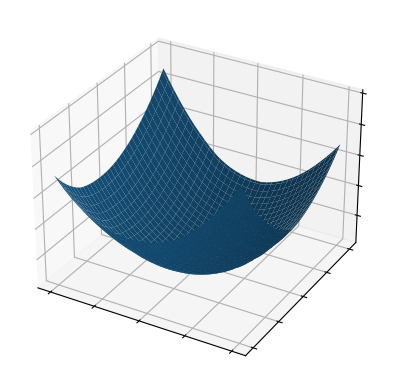

In [ ]:

i = 9

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.plot_surface(points[:, :, 0], points[:, :, 1], mse[i])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

plt.show()

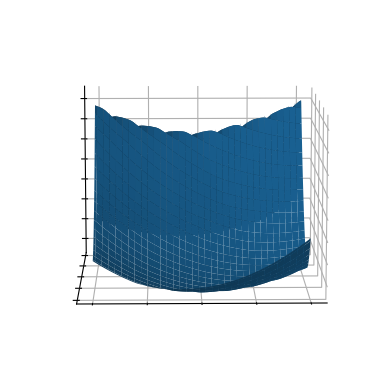

/var/folders/l8/m2glkk_557l1j7xyp1qbh99m0000gp/T/ipykernel_88549/1134383596.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


In [ ]:
i = 5

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

def init():
    ax.plot_surface(points[:, :, 0], points[:, :, 1], mse[i])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))

def update(frame):
    ax.view_init(elev = 10, azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450), init_func = init)
writer = pltanim.PillowWriter(fps = 30)
# animation.save(f"cov_presentation/loss_{i}.gif", writer = writer)
plt.show()

# Presentation

In [933]:
f = lambda x: (torch.as_tensor([1.0, 1.0])*x**2).sum(-1)
chol_params = torch.nn.Parameter(torch.zeros([latent_dims[0], latent_dims[0]]))
pz_x = torch.distributions.MultivariateNormal
optimizer = torch.optim.Adam([chol_params], lr = 1e-4)
latent_mean = torch.as_tensor([0.0, 0.0])
for epoch in range(10000):
    diagonals = torch.nn.functional.softplus(torch.diagonal(chol_params, 0, -2, -1)) + 1e-10
    chol = torch.diag_embed(diagonals) + torch.tril(chol_params, -1)
    gauss_samples = pz_x(latent_mean, scale_tril = chol).rsample(torch.Size([100]))
    recon_samples = f(gauss_samples)
    recon_mean = f(latent_mean)
    trace_loss = chol.square().mean(0).sum()
    det_loss = -2*torch.log(torch.diagonal(chol, 0, -2, -1)).sum(-1).mean()
    recon_loss = torch.square(recon_samples - recon_mean[None]).mean()
    loss = recon_loss + trace_loss + det_loss
    loss.backward()
    optimizer.step()
    print(f"{epoch + 1}/1000: {loss.item():.4f}")
pz_x = pz_x(latent_mean, scale_tril = chol)

1/1000: 3.0419
2/1000: 4.0935
3/1000: 3.8090
4/1000: 4.0894
5/1000: 3.0906
6/1000: 3.6092
7/1000: 3.6269
8/1000: 3.3643
9/1000: 4.3960
10/1000: 4.0612
11/1000: 3.9063
12/1000: 3.4770
13/1000: 3.8167
14/1000: 4.0639
15/1000: 4.0855
16/1000: 3.8853
17/1000: 3.5350
18/1000: 3.6560
19/1000: 3.5711
20/1000: 3.4618
21/1000: 3.8809
22/1000: 3.3643
23/1000: 4.0881
24/1000: 4.5197
25/1000: 3.6879
26/1000: 3.3494
27/1000: 3.9679
28/1000: 3.9798
29/1000: 3.7659
30/1000: 4.2754
31/1000: 4.0117
32/1000: 3.6672
33/1000: 3.4591
34/1000: 4.6186
35/1000: 3.6171
36/1000: 3.8093
37/1000: 3.4691
38/1000: 3.8173
39/1000: 4.5416
40/1000: 3.6072
41/1000: 3.8603
42/1000: 3.3711
43/1000: 4.0257
44/1000: 3.6210
45/1000: 3.8684
46/1000: 3.8238
47/1000: 3.9832
48/1000: 3.1241
49/1000: 3.7301
50/1000: 3.6114
51/1000: 3.6189
52/1000: 3.5256
53/1000: 3.1902
54/1000: 3.6272
55/1000: 4.3073
56/1000: 3.4135
57/1000: 3.8062
58/1000: 4.1095
59/1000: 3.4066
60/1000: 3.3895
61/1000: 4.2122
62/1000: 3.3149
63/1000: 3.0873
6

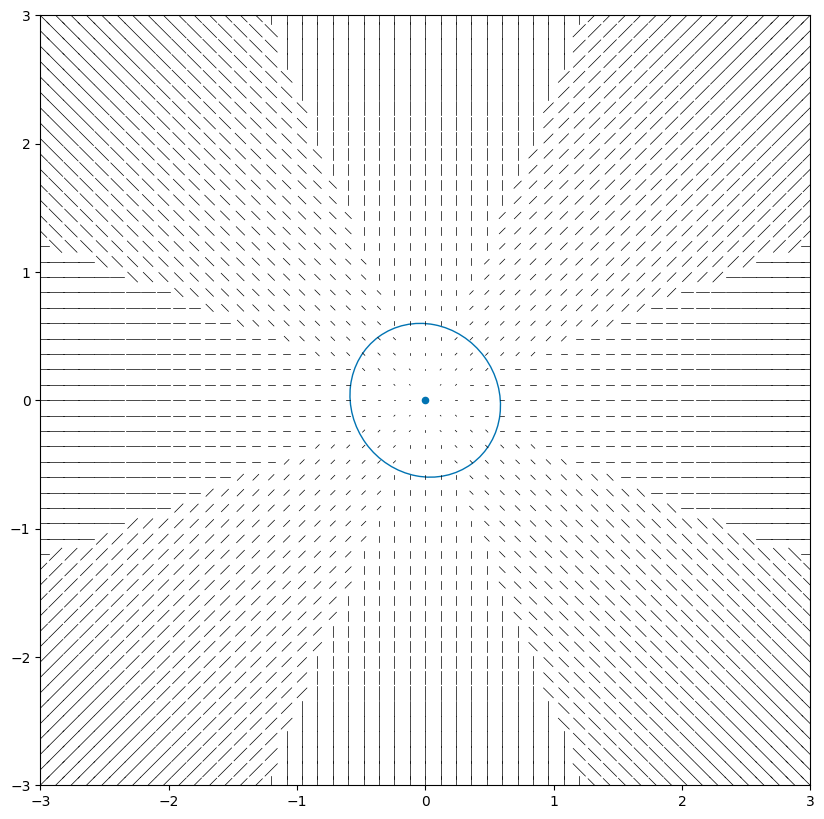

In [934]:
(eigs, vecs) = torch.linalg.eigh(4*pz_x.covariance_matrix)
rots = 180*torch.arccos(vecs[1, 0])/np.pi

(fig, ax) = plt.subplots(1, 1, figsize = (10, 10))
plot_latent(latent_mean[None], [0], eigs[None], rots[None], ax, f, colors)
ax.set_aspect("equal")
plt.savefig("x2y2_sym.png", bbox_inches = "tight")
plt.show()

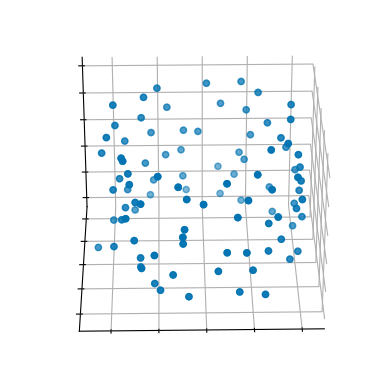

In [1035]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

def init():
    color_indices = [colors[i] for i in cluster_labels[:100]]
    ax.scatter(samples[0][::100, 0], samples[0][::100, 1], samples[0][::100, 2], 
               color = color_indices)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))

def update(frame):
    ax.view_init(azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450), init_func = init)
writer = pltanim.PillowWriter(fps = 30)
animation.save("cov_presentation/ae_input_test.gif", writer = writer, savefig_kwargs = dict(facecolor='#FFFFFF'))


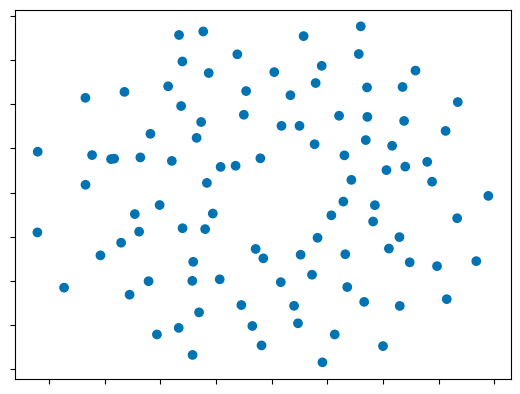

In [1044]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(means[(0, 0)][:100, 0], means[(0, 0)][:100, 1], color = [colors[i] for i in cluster_labels[:100]])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.savefig("cov_presentation/ae_latent_test.png")

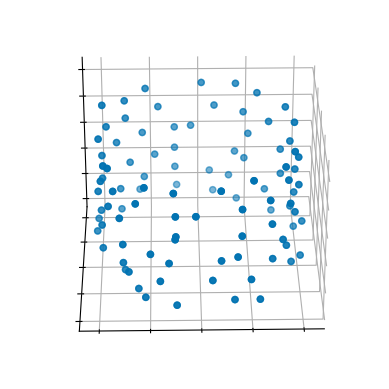

In [1045]:

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

def init():
    data = recons[(0, 0)]
    color_indices = [colors[i] for i in cluster_labels[::100]]
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], 
               color = color_indices)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))

def update(frame):
    ax.view_init(azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450), init_func = init)
writer = pltanim.PillowWriter(fps = 30)
animation.save("cov_presentation/ae_output_test.gif", writer = writer)

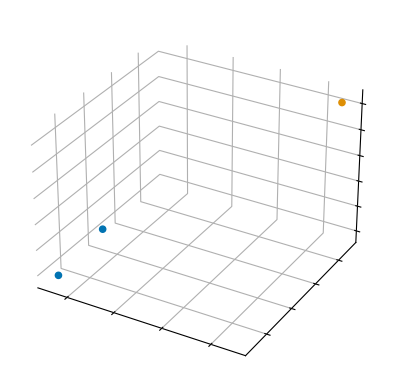

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.scatter(samples[0][:3, 0], samples[0][:3, 1], samples[0][:3, 2], color = [colors[i] for i in cluster_labels[:3]], depthshade = False)
ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
plt.savefig("cov_presentation/vae_input.png")

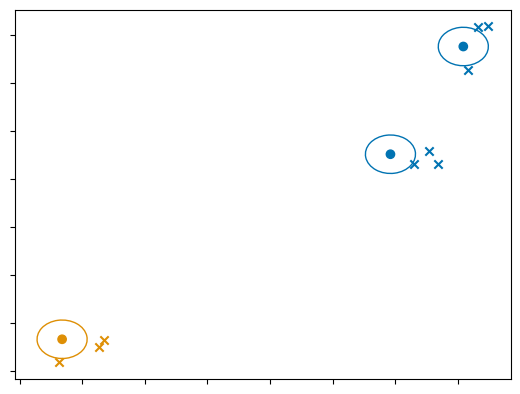

In [ ]:

plt_means = means[(0, 0)][:3]
plt_expanded_means = plt_means[:, None].expand(-1, 3, -1)
plt_samples = plt_expanded_means + 0.1*torch.randn_like(plt_expanded_means)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(plt_means[:, 0], plt_means[:, 1], color = [colors[i] for i in cluster_labels[:3]])
for ((x_0, y_0), sample_set, color_i) in zip(plt_means, plt_samples, cluster_labels):
    ellipse = Ellipse(xy = (x_0, y_0), width = 0.2, height = 0.2, angle = angle, edgecolor = colors[color_i], fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    for (x, y) in sample_set:
        ax.scatter([x], [y], marker = "x", color = colors[color_i])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.savefig("cov_presentation/vae_latent.png")

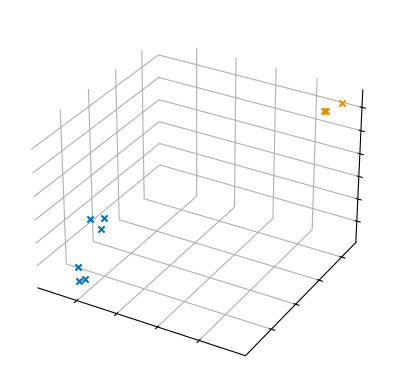

In [ ]:
plt_mean_recons = recons[(input_modal, output_modal)][:3]

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
# ax.scatter(plt_mean_recons[:, 0], plt_mean_recons[:, 1], plt_mean_recons[:, 2], color = [colors[i] for i in cluster_labels[:3]], depthshade = False)
for (sample_set, color_i) in zip(plt_samples, cluster_labels):
    with torch.no_grad():
        plt_recon = decoders[0](sample_set)
    ax.scatter(plt_recon[:, 0], plt_recon[:, 1], plt_recon[:, 2], color = colors[color_i], depthshade = False, marker = "x")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
plt.savefig("cov_presentation/vae_output.png")

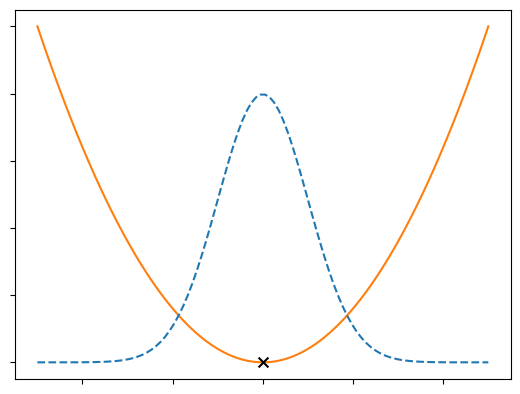

In [ ]:
x_points = torch.linspace(-5, 5, 100)
gaussian_points = torch.exp(-0.5*x_points**2)/(2*np.pi)**0.5
quadratic = 0.02*x_points**2
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_points, gaussian_points, linestyle = "dashed", zorder = 1)
ax.plot(x_points, quadratic, zorder = 0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.scatter([0], [0], color = "black", marker = "x", s = 50, zorder = 2)
plt.savefig("cov_presentation/1d_loss_optimal.png")

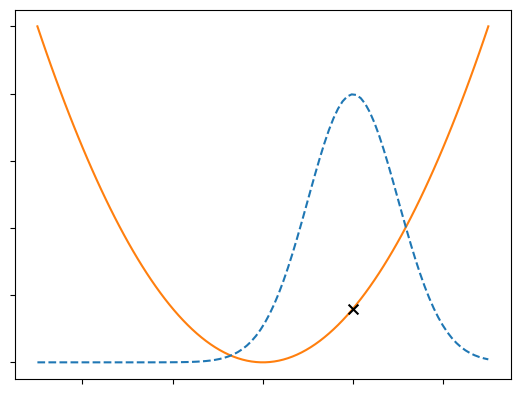

In [ ]:
x_points = torch.linspace(-5, 5, 100)
gaussian_points = torch.exp(-0.5*(x_points - 2)**2)/(2*np.pi)**0.5
quadratic = 0.02*x_points**2
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_points, gaussian_points, linestyle = "dashed", zorder = 1)
ax.plot(x_points, quadratic, zorder = 0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.scatter([2], [0.02*2**2], color = "black", marker = "x", s = 50, zorder = 2)
plt.savefig("cov_presentation/1d_loss_quad.png")

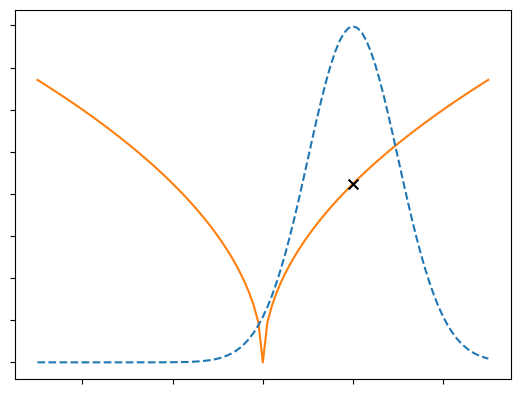

In [ ]:
x_points = torch.linspace(-5, 5, 101)
gaussian_points = torch.exp(-0.5*(x_points - 2)**2)/(2*np.pi)**0.5
sharp_well = 1.5*abs(0.01*x_points)**0.5
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_points, gaussian_points, linestyle = "dashed", zorder = 1)
ax.plot(x_points, sharp_well, zorder = 0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.scatter([2], [1.5*0.02**0.5], color = "black", marker = "x", s = 50, zorder = 2)
plt.savefig("cov_presentation/1d_loss_root.png")